<a href="https://colab.research.google.com/github/masterAristocats/Trabalho-Processamento-de-Sinais-I-7/blob/main/rep.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Exercício Pratico 7 - Projeto de Filtros FIR



1. Considerando um fs = 20000 Hz, projete os
seguintes filtros FIR de ordem M ∈ {20, 50, 100} para as
janelas retangular, triangular, Bartlett, Hamming, Hann
e Blackman. Apresente a resposta ao impulso, o diagrama de polos e zeros e a resposta em frequência dos
filtros projetados. Comente os resultados obtidos.


(a) Passa-baixas com fc = 1000 Hz.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000      # Hz
fc = 1000       # Hz

wc = 2*np.pi*fc/fs

ordens = [20, 50, 100]

def ideal_lowpass(M, wc):
    n = np.arange(-M//2, M//2 + 1)

    h = np.zeros(len(n))

    for i, ni in enumerate(n):
        if ni == 0:
            h[i] = wc/np.pi
        else:
            h[i] = np.sin(wc*ni)/(np.pi*ni)

    return h

In [2]:
def triangular_window(M):
    n = np.arange(-M//2, M//2 + 1)
    return -2*np.abs(n)/(M+2) + 1

def bartlett_window(M):
    n = np.arange(-M//2, M//2 + 1)
    return -2*np.abs(n)/M + 1

def get_windows(M):
    return {
        'Retangular': np.ones(M+1),
        'Triangular': triangular_window(M),
        'Bartlett': bartlett_window(M),
        'Hamming': np.hamming(M+1),
        'Hann': np.hanning(M+1),
        'Blackman': np.blackman(M+1)
    }

In [3]:
filtros = {}

for M in ordens:

    h_ideal = ideal_lowpass(M, wc)

    filtros[M] = {}

    for nome, janela in get_windows(M).items():

        h = h_ideal * janela

        filtros[M][nome] = h

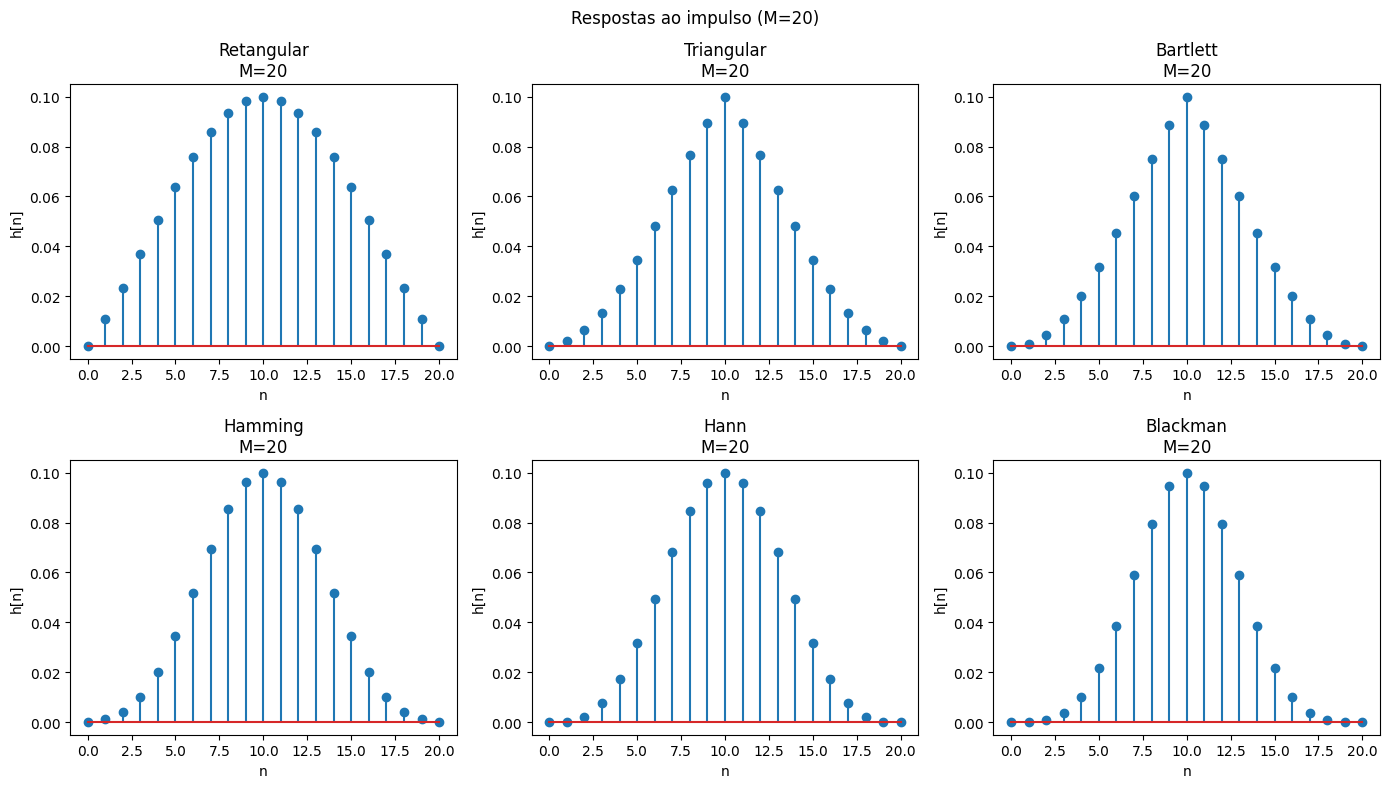

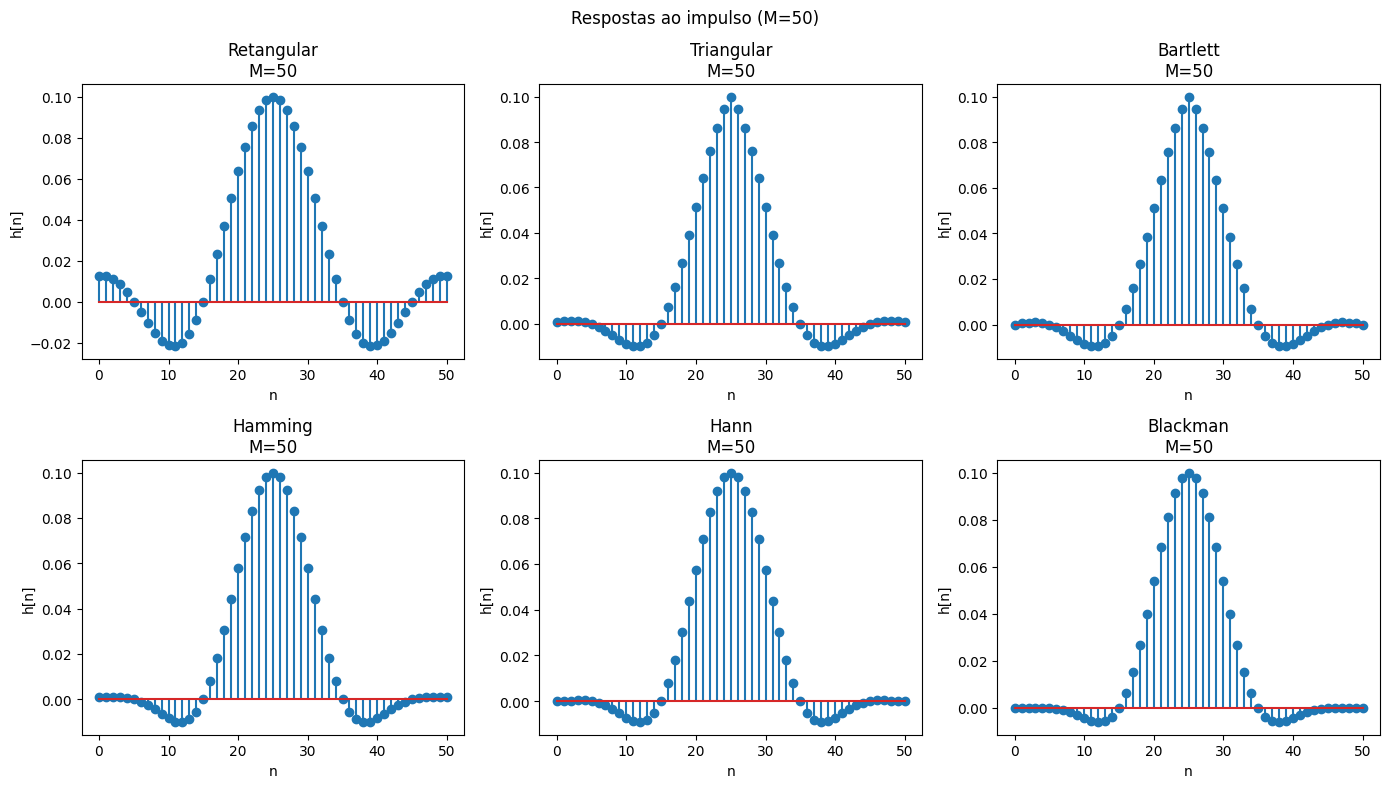

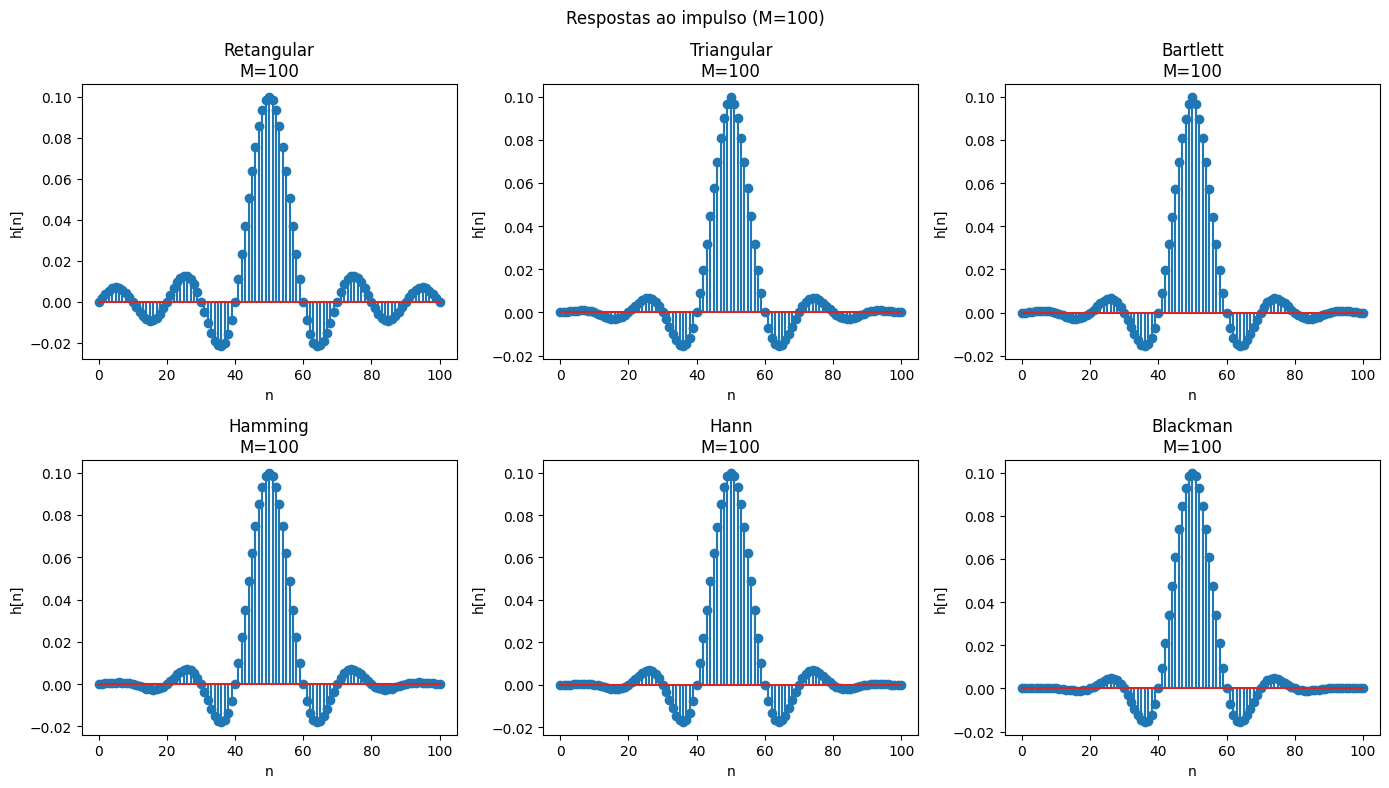

In [4]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        plt.stem(h)
        plt.title(f'{nome}\nM={M}')
        plt.xlabel('n')
        plt.ylabel('h[n]')

    plt.suptitle(f'Respostas ao impulso (M={M})')
    plt.tight_layout()
    plt.show()

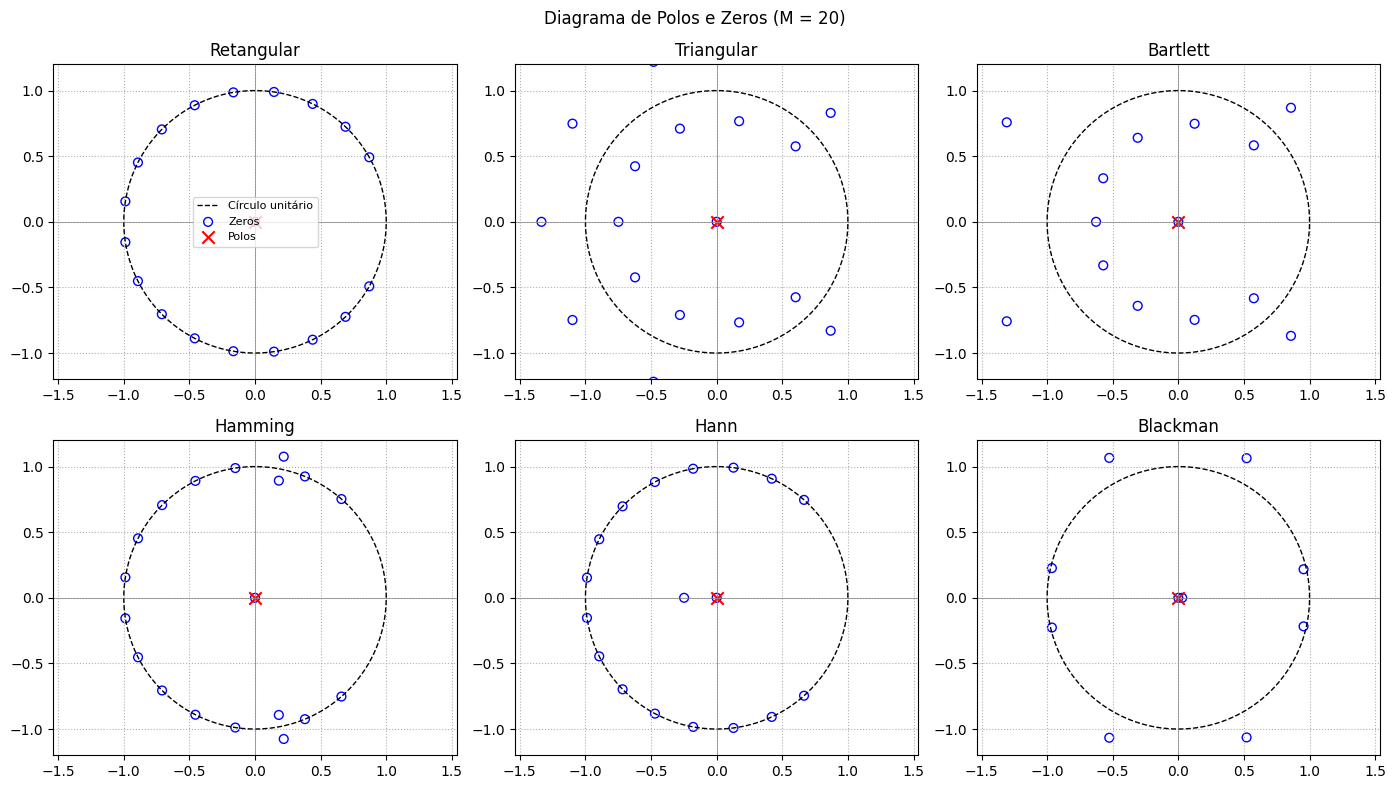

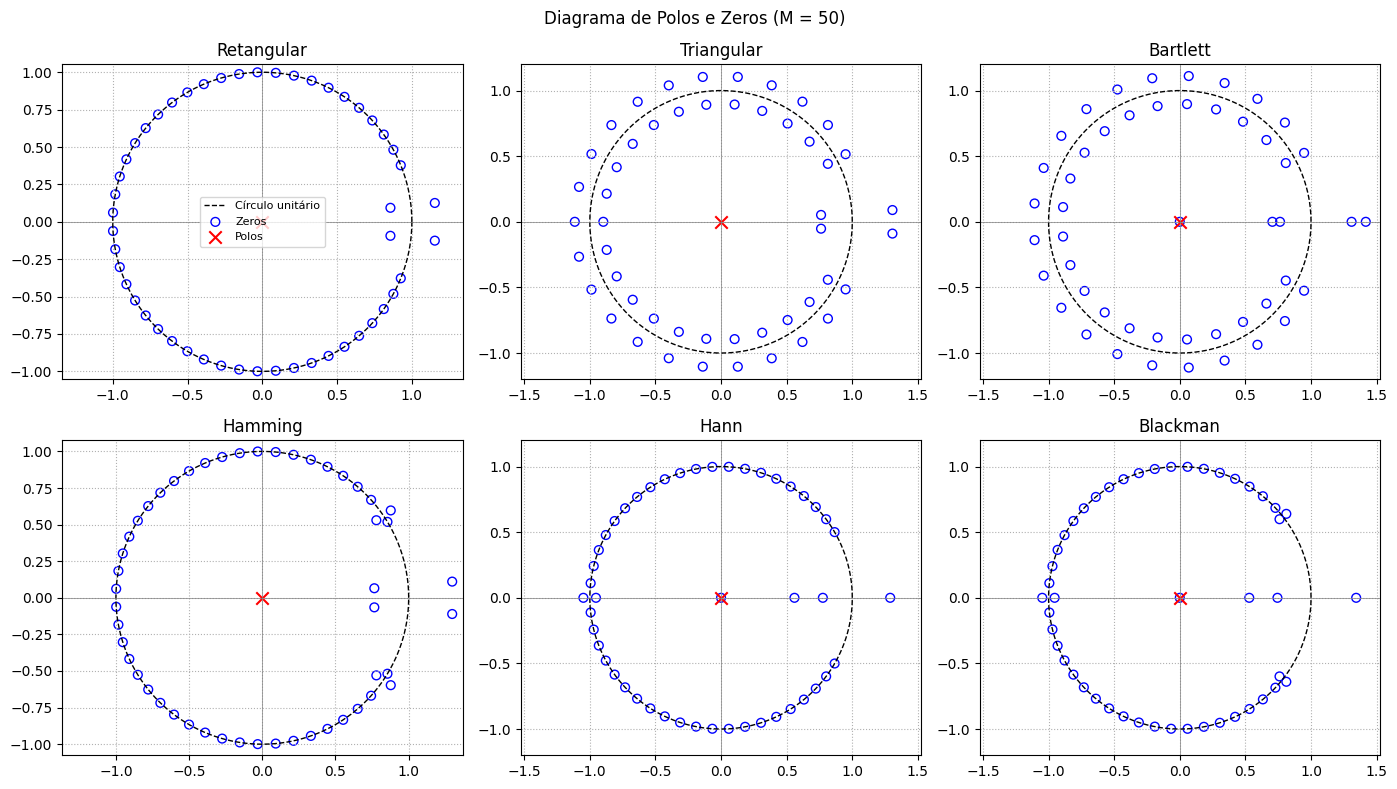

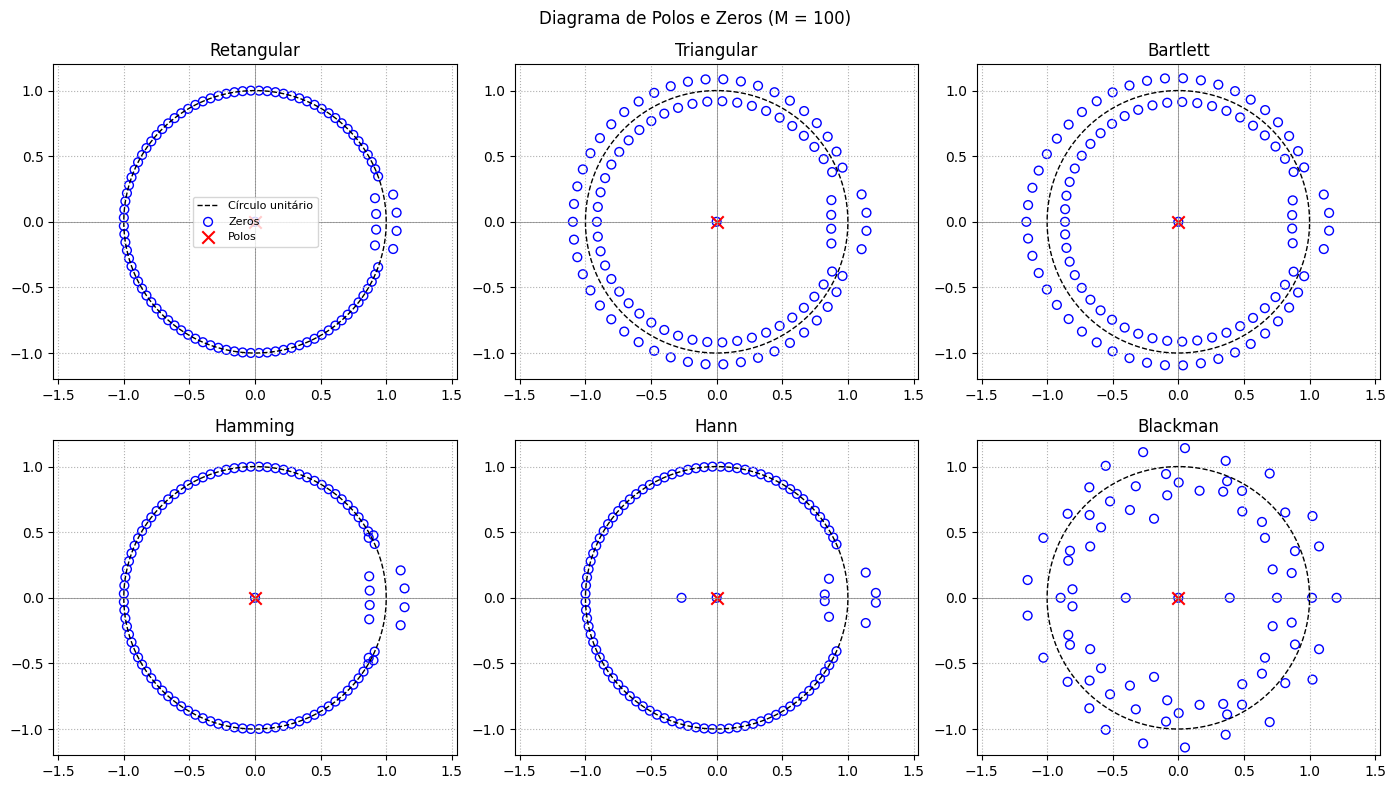

In [7]:
for M in ordens:

    plt.figure(figsize=(14, 8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2, 3, i)

        # Zeros do filtro FIR
        zeros = np.roots(h)

        # Círculo unitário
        ang = np.linspace(0, 2*np.pi, 500)
        plt.plot(np.cos(ang),
                 np.sin(ang),
                 'k--',
                 linewidth=1,
                 label='Círculo unitário')

        # Zeros
        plt.scatter(np.real(zeros),
                    np.imag(zeros),
                    marker='o',
                    facecolors='none',
                    edgecolors='b',
                    s=40,
                    label='Zeros')

        # Polo na origem (representação didática)
        plt.scatter(0,
                    0,
                    marker='x',
                    color='r',
                    s=80,
                    label='Polos')

        # Configuração dos eixos
        plt.axhline(0, color='gray', linewidth=0.5)
        plt.axvline(0, color='gray', linewidth=0.5)

        plt.axis('equal')
        plt.xlim(-1.2, 1.2)
        plt.ylim(-1.2, 1.2)

        plt.grid(True, linestyle=':')
        plt.title(f'{nome}')

        # Mostrar legenda apenas no primeiro gráfico
        if i == 1:
            plt.legend(fontsize=8)

    plt.suptitle(f'Diagrama de Polos e Zeros (M = {M})')
    plt.tight_layout()
    plt.show()

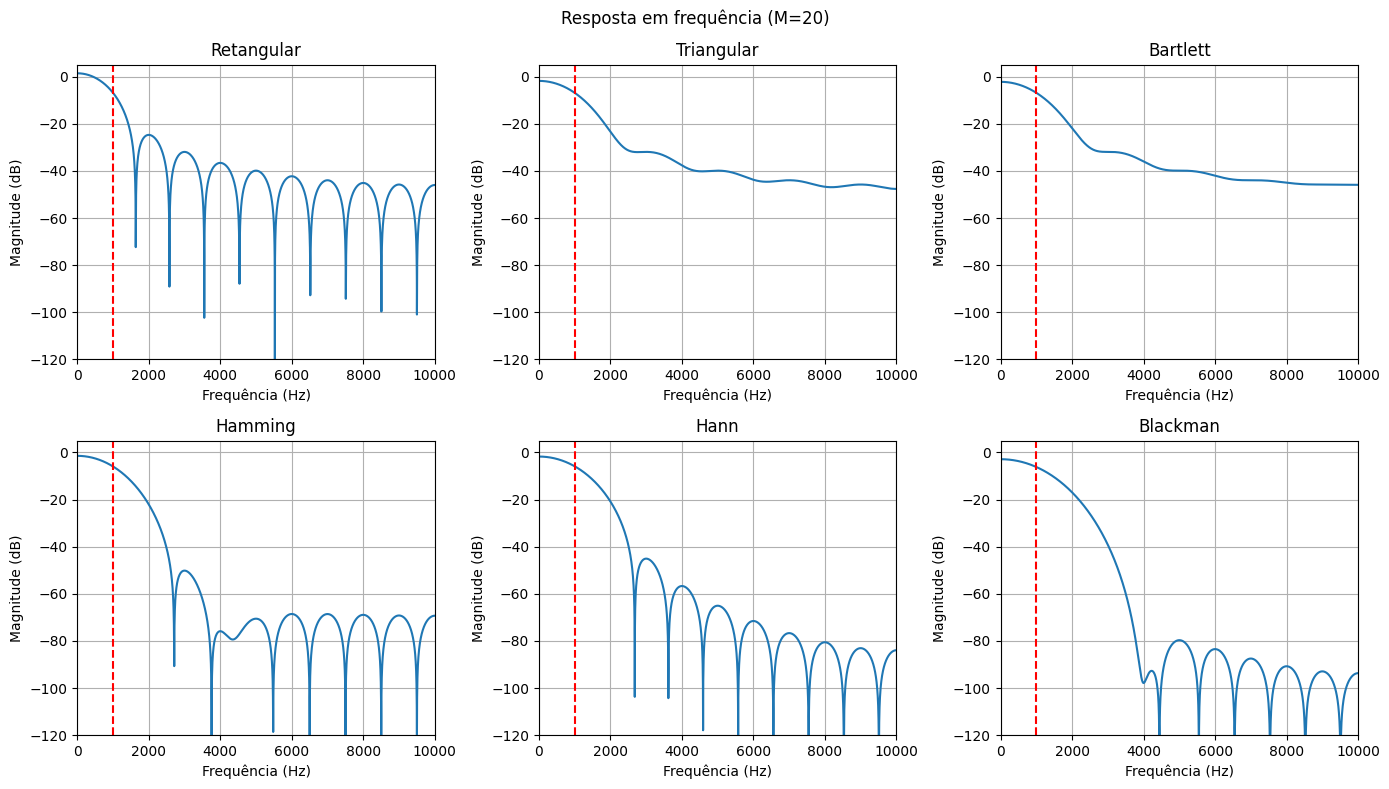

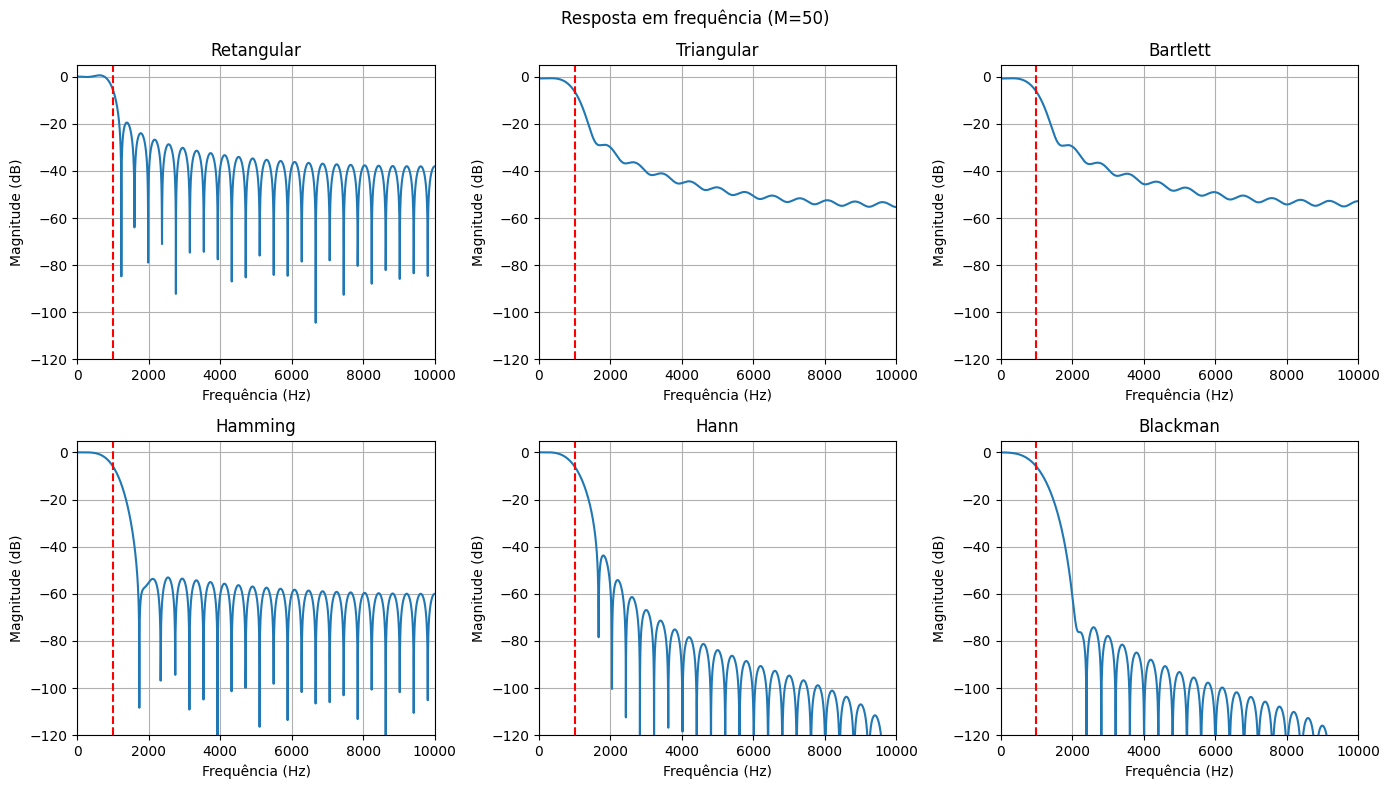

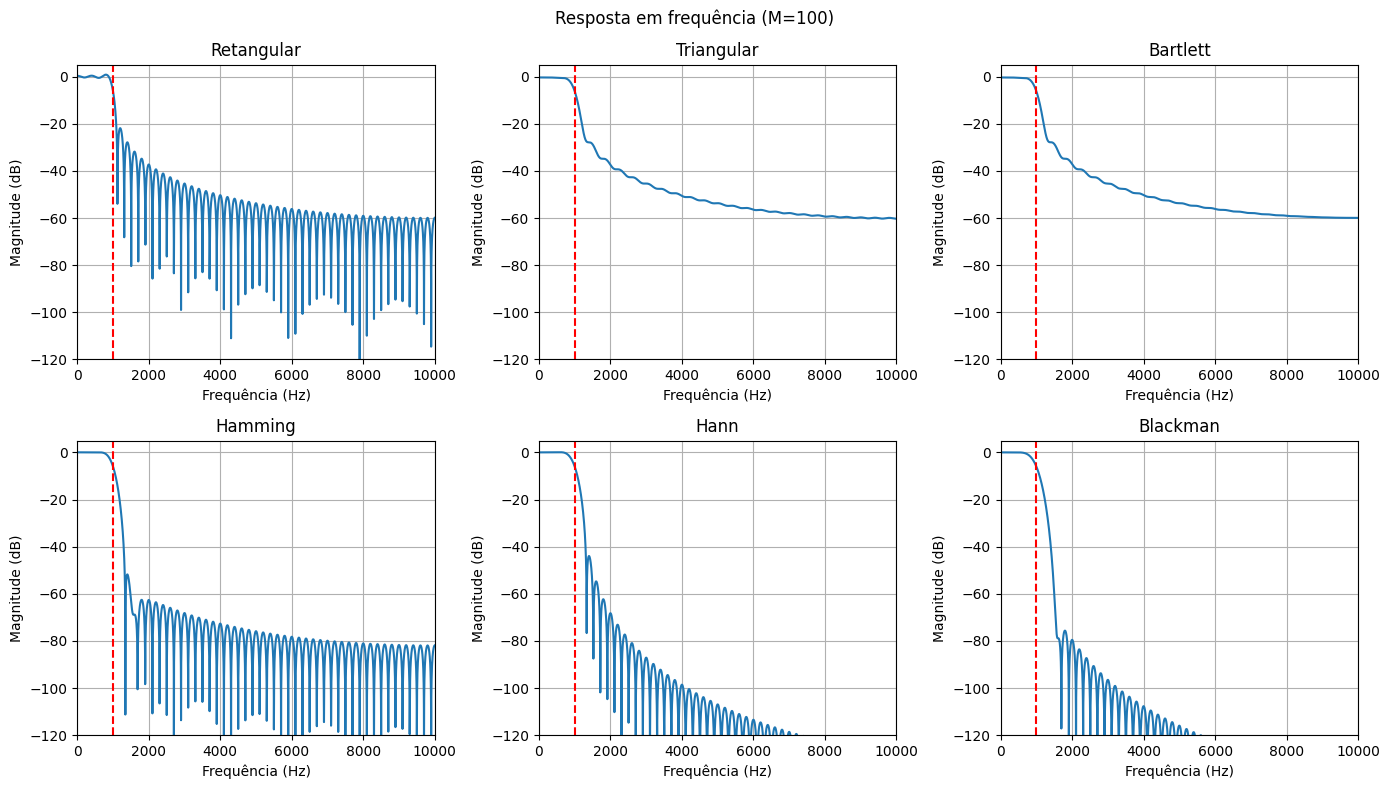

In [6]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        w, H = signal.freqz(h, worN=4096)

        f = w*fs/(2*np.pi)

        plt.plot(f,
                 20*np.log10(np.abs(H)+1e-10))

        plt.axvline(fc,
                    color='r',
                    linestyle='--',
                    label='fc')

        plt.xlim(0, fs/2)
        plt.ylim(-120, 5)

        plt.grid()

        plt.title(nome)
        plt.xlabel('Frequência (Hz)')
        plt.ylabel('Magnitude (dB)')

    plt.suptitle(f'Resposta em frequência (M={M})')
    plt.tight_layout()
    plt.show()

(b) Passa-altas com fc = 2000 Hz.

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000      # Frequência de amostragem (Hz)
fc = 2000       # Frequência de corte (Hz)

wc = 2 * np.pi * fc / fs

ordens = [20, 50, 100]

def ideal_highpass(M, wc):

    n = np.arange(-M//2, M//2 + 1)

    h = np.zeros(len(n))

    for i, ni in enumerate(n):

        if ni == 0:
            h[i] = 1 - wc/np.pi
        else:
            h[i] = -np.sin(wc * ni) / (np.pi * ni)

    return h

In [9]:
def triangular_window(M):

    n = np.arange(-M//2, M//2 + 1)

    return -2*np.abs(n)/(M+2) + 1

def bartlett_window(M):

    n = np.arange(-M//2, M//2 + 1)

    return -2*np.abs(n)/M + 1

def get_windows(M):

    return {
        'Retangular': np.ones(M+1),
        'Triangular': triangular_window(M),
        'Bartlett': bartlett_window(M),
        'Hamming': np.hamming(M+1),
        'Hann': np.hanning(M+1),
        'Blackman': np.blackman(M+1)
    }

In [10]:
filtros = {}

for M in ordens:

    h_ideal = ideal_highpass(M, wc)

    filtros[M] = {}

    for nome, janela in get_windows(M).items():

        h = h_ideal * janela

        filtros[M][nome] = h

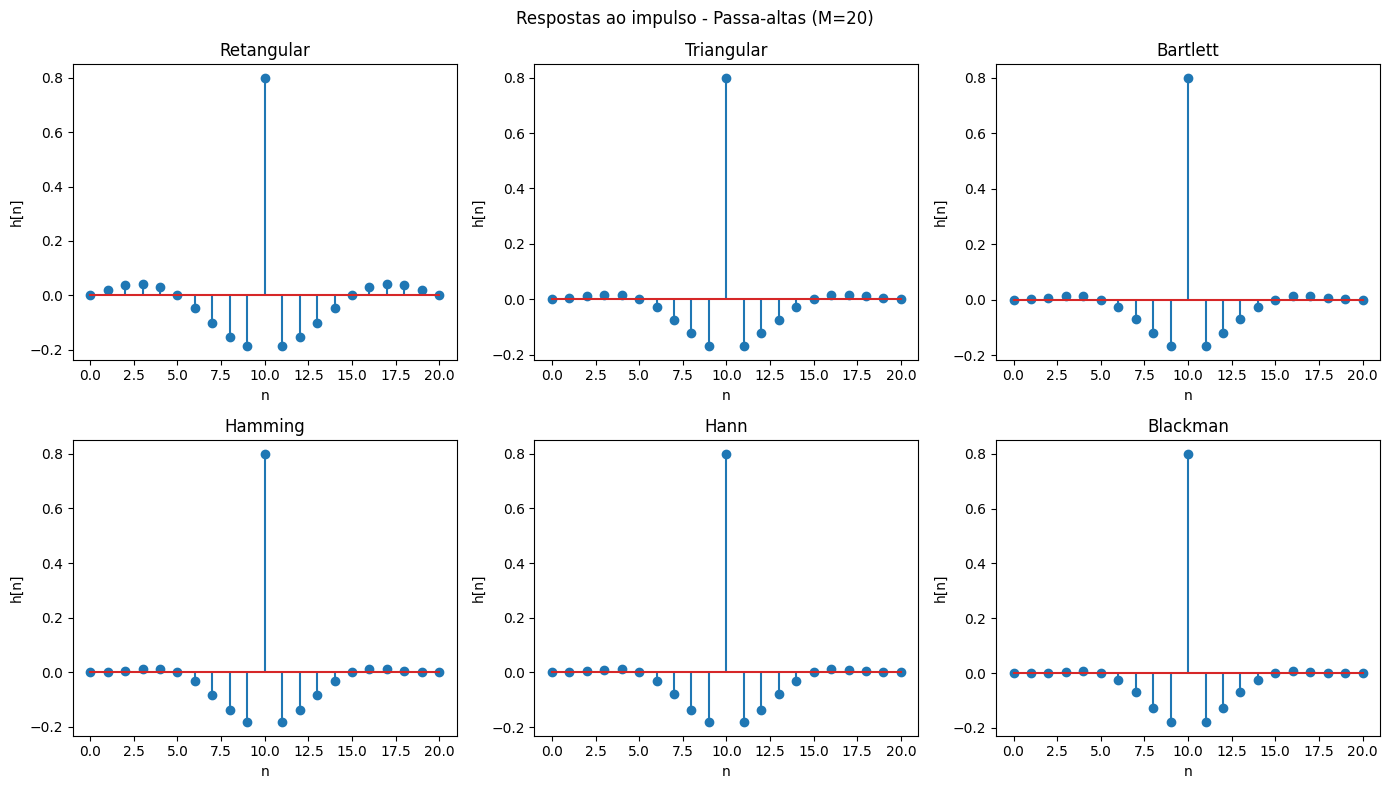

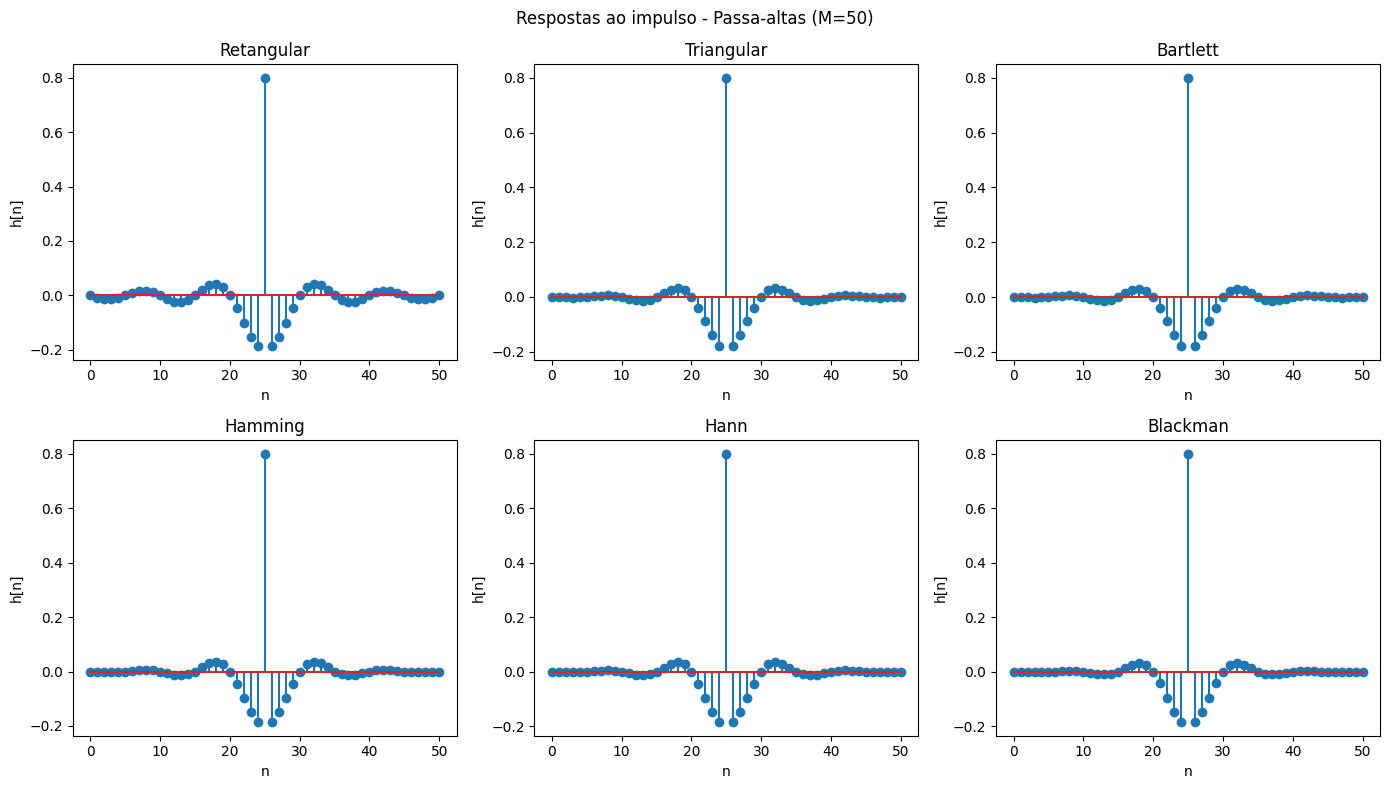

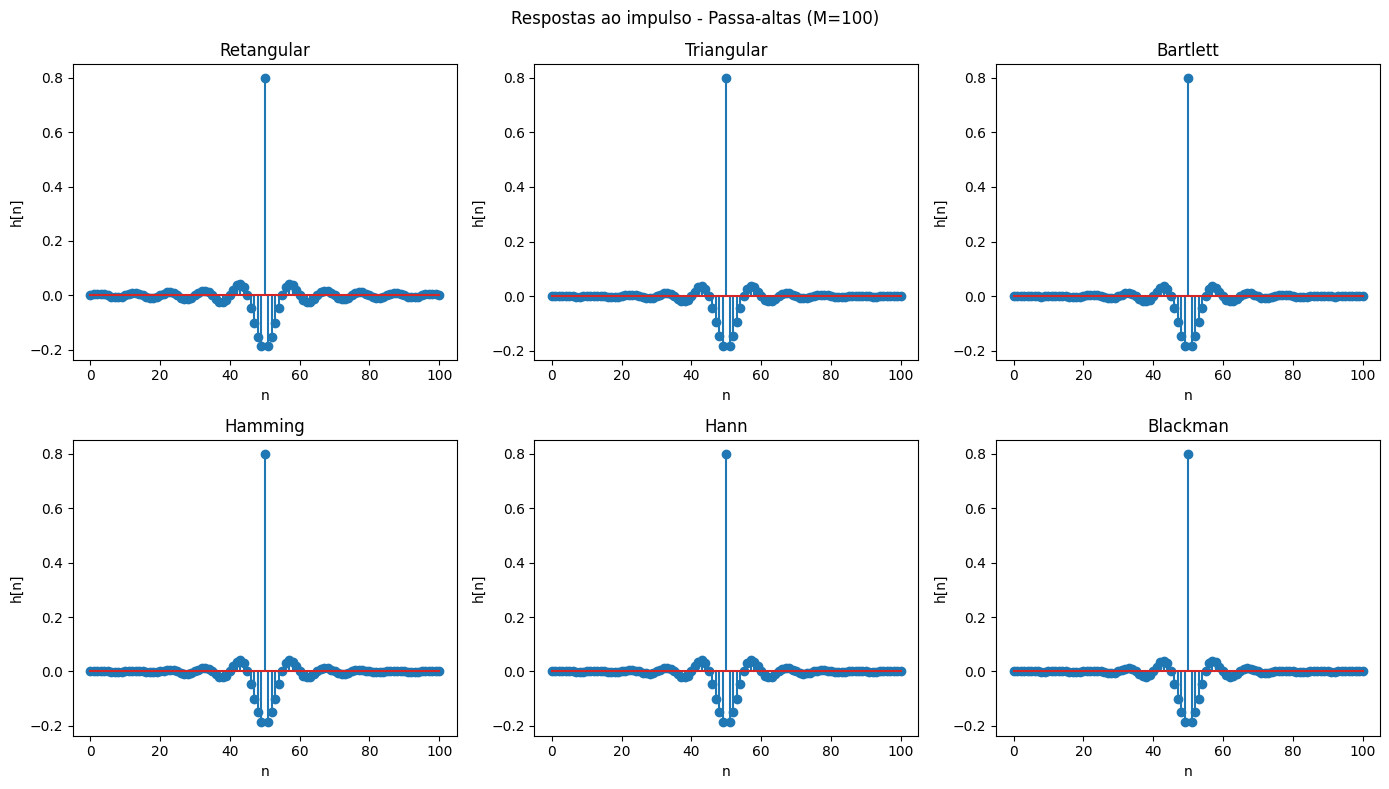

In [11]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        plt.stem(h)

        plt.title(nome)
        plt.xlabel('n')
        plt.ylabel('h[n]')

    plt.suptitle(f'Respostas ao impulso - Passa-altas (M={M})')

    plt.tight_layout()

    plt.show()

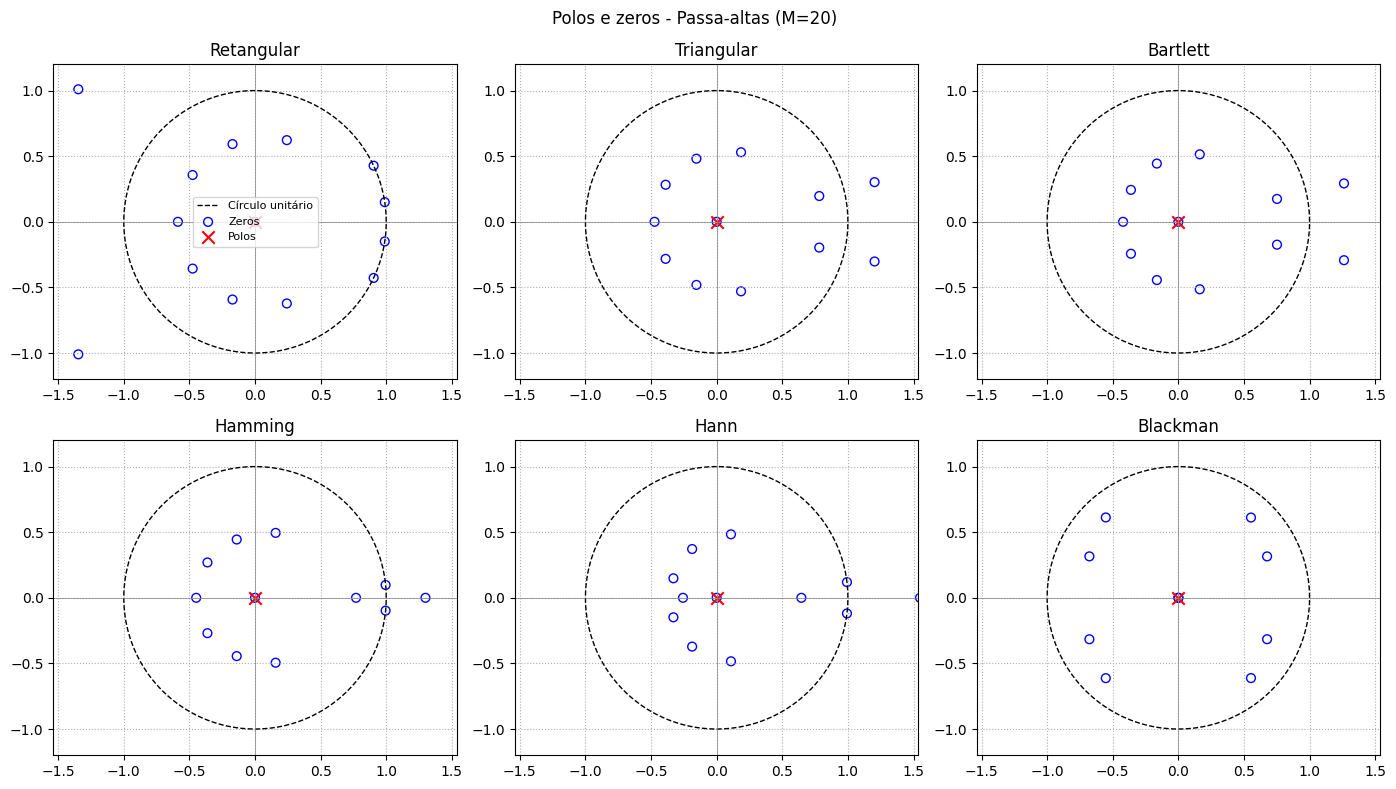

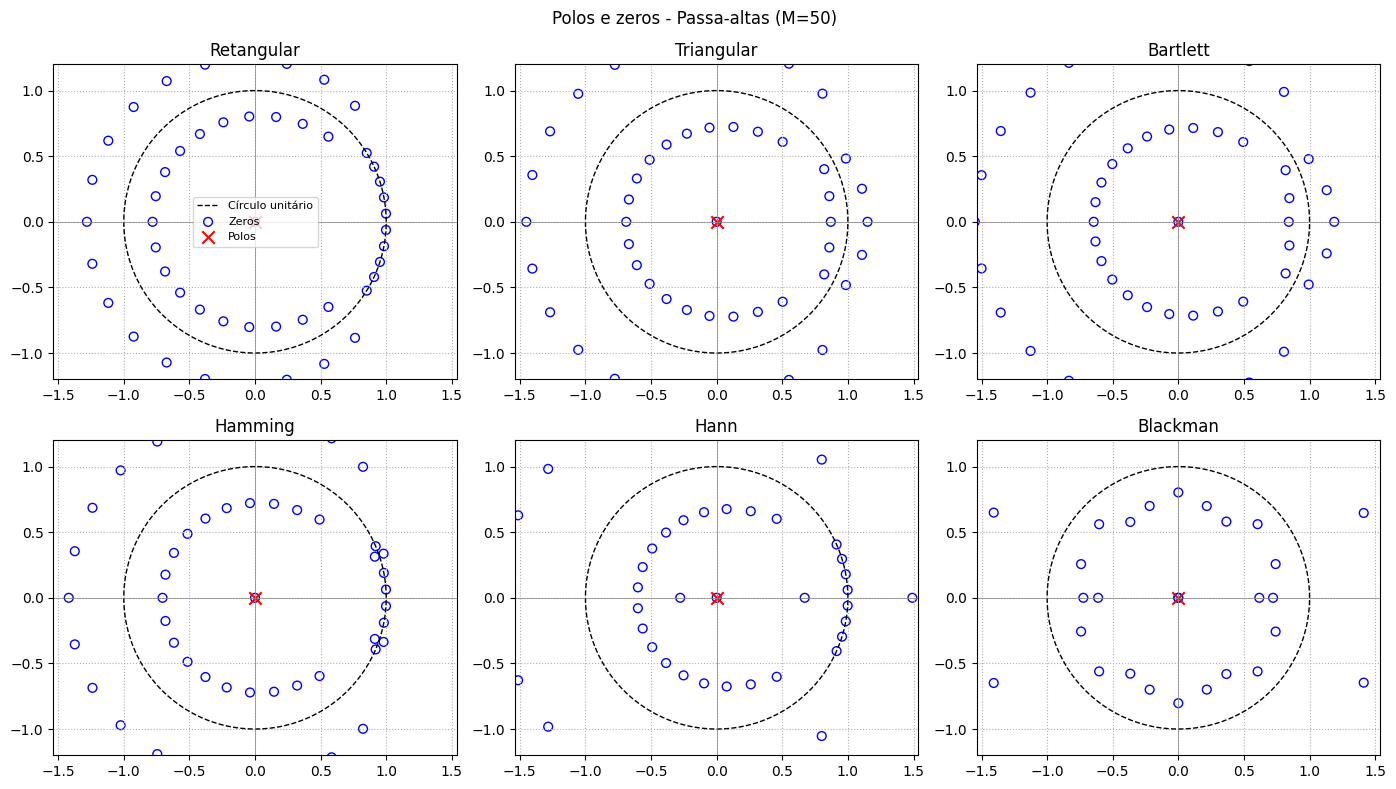

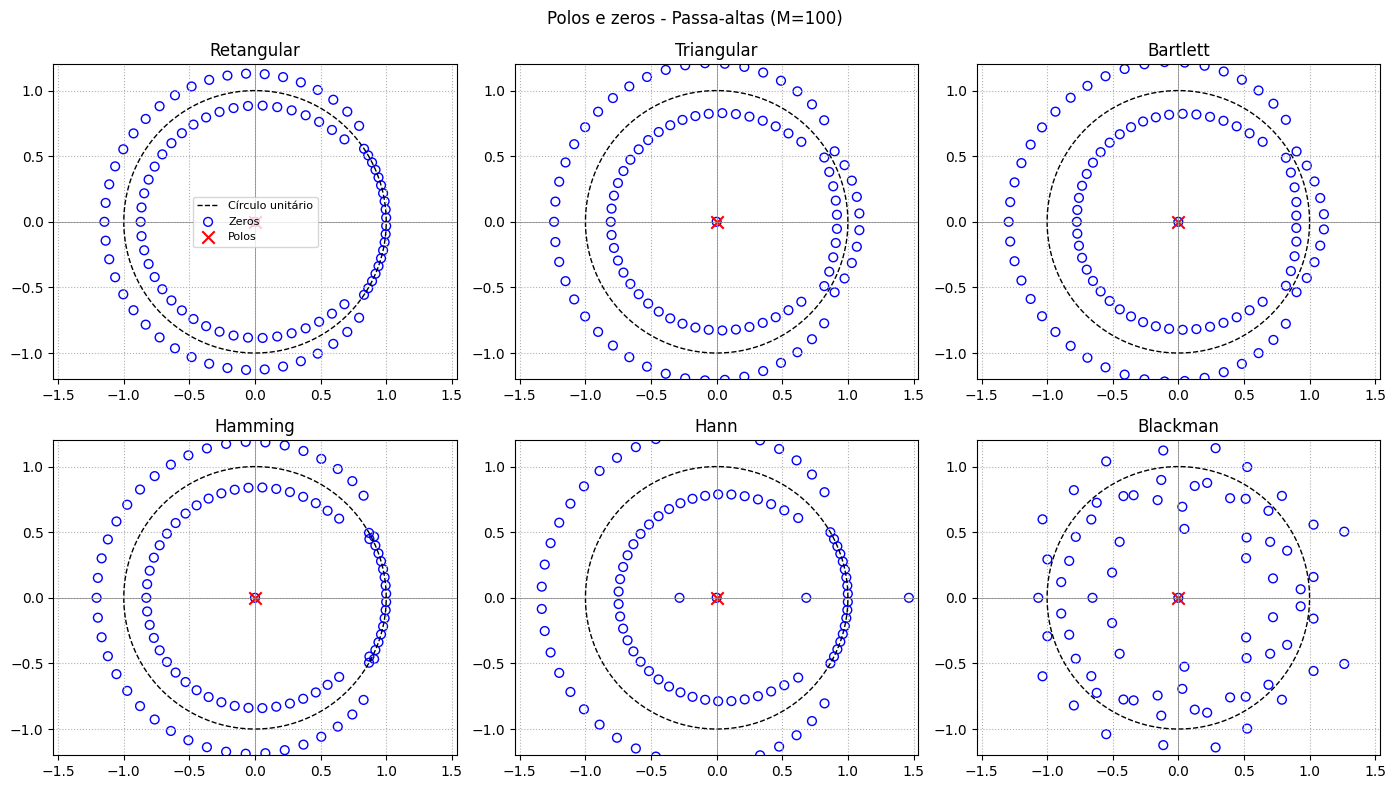

In [12]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        zeros = np.roots(h)

        ang = np.linspace(0, 2*np.pi, 500)

        plt.plot(np.cos(ang),
                 np.sin(ang),
                 'k--',
                 linewidth=1,
                 label='Círculo unitário')

        plt.scatter(np.real(zeros),
                    np.imag(zeros),
                    marker='o',
                    facecolors='none',
                    edgecolors='b',
                    s=40,
                    label='Zeros')

        plt.scatter(0,
                    0,
                    marker='x',
                    color='r',
                    s=80,
                    label='Polos')

        plt.axhline(0, color='gray', linewidth=0.5)
        plt.axvline(0, color='gray', linewidth=0.5)

        plt.axis('equal')
        plt.xlim(-1.2, 1.2)
        plt.ylim(-1.2, 1.2)

        plt.grid(True, linestyle=':')

        plt.title(nome)

        if i == 1:
            plt.legend(fontsize=8)

    plt.suptitle(f'Polos e zeros - Passa-altas (M={M})')

    plt.tight_layout()

    plt.show()

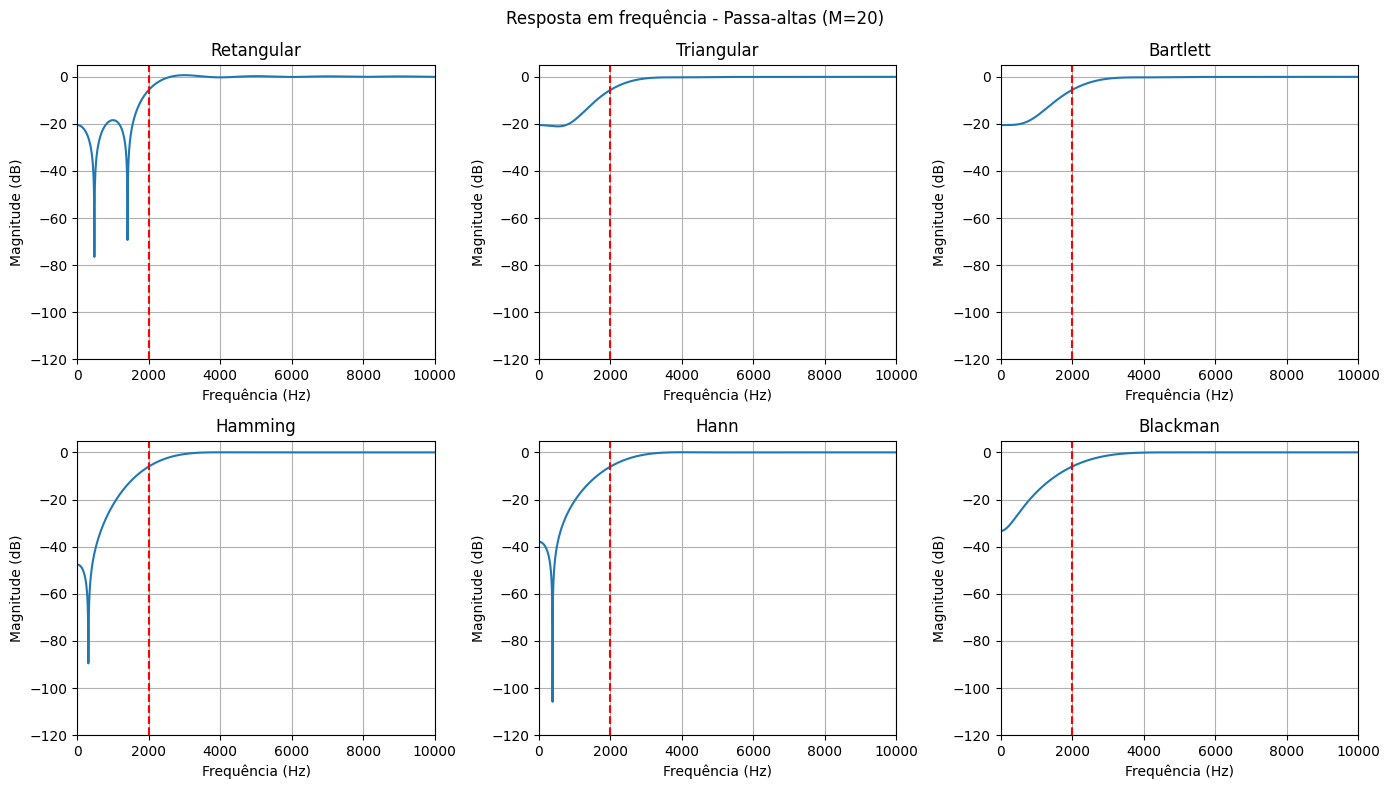

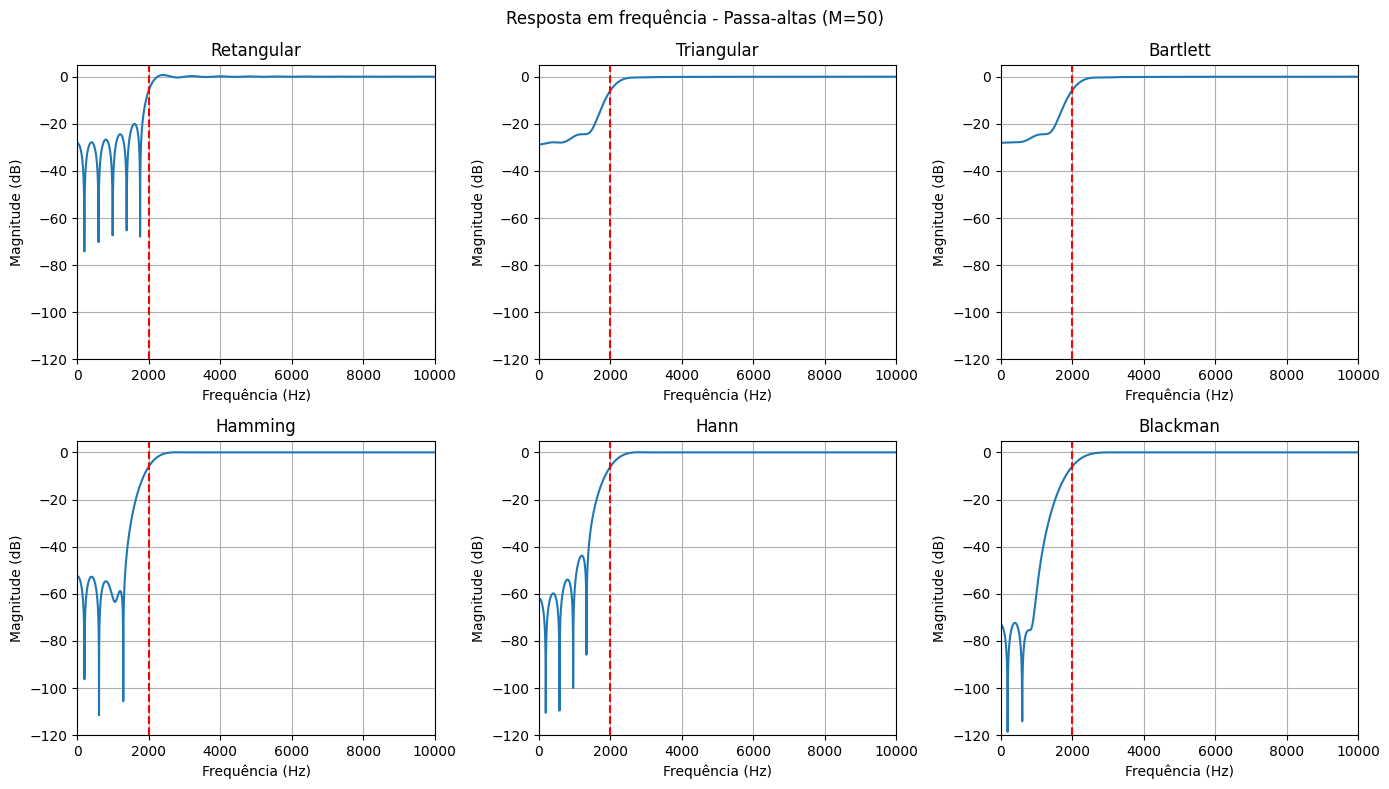

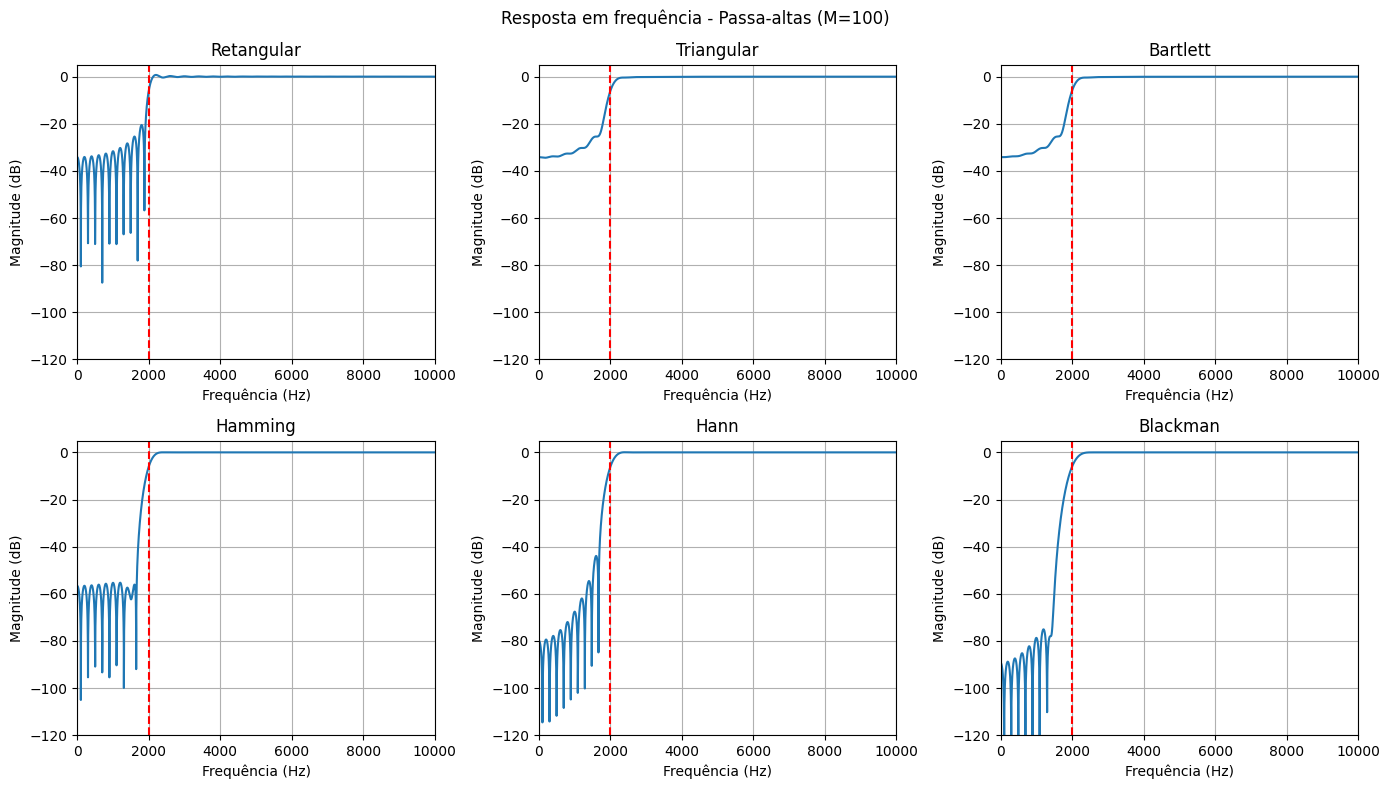

In [13]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        w, H = signal.freqz(h, worN=4096)

        f = w * fs / (2*np.pi)

        plt.plot(f,
                 20*np.log10(np.abs(H) + 1e-10))

        plt.axvline(fc,
                    color='r',
                    linestyle='--',
                    label='fc')

        plt.xlim(0, fs/2)
        plt.ylim(-120, 5)

        plt.grid()

        plt.title(nome)

        plt.xlabel('Frequência (Hz)')
        plt.ylabel('Magnitude (dB)')

    plt.suptitle(f'Resposta em frequência - Passa-altas (M={M})')

    plt.tight_layout()

    plt.show()

(c) Passa-faixas com fc1 = 500 Hz, fc2 = 2000 Hz.

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000      # Hz

fc1 = 500       # Hz
fc2 = 2000      # Hz

wc1 = 2*np.pi*fc1/fs
wc2 = 2*np.pi*fc2/fs

ordens = [20, 50, 100]

def ideal_bandpass(M, wc1, wc2):

    n = np.arange(-M//2, M//2 + 1)

    h = np.zeros(len(n))

    for i, ni in enumerate(n):

        if ni == 0:
            h[i] = (wc2 - wc1)/np.pi
        else:
            h[i] = (np.sin(wc2*ni) - np.sin(wc1*ni)) / (np.pi*ni)

    return h

In [15]:
def triangular_window(M):

    n = np.arange(-M//2, M//2 + 1)

    return -2*np.abs(n)/(M+2) + 1

def bartlett_window(M):

    n = np.arange(-M//2, M//2 + 1)

    return -2*np.abs(n)/M + 1

def get_windows(M):

    return {
        'Retangular': np.ones(M+1),
        'Triangular': triangular_window(M),
        'Bartlett': bartlett_window(M),
        'Hamming': np.hamming(M+1),
        'Hann': np.hanning(M+1),
        'Blackman': np.blackman(M+1)
    }

In [16]:
filtros = {}

for M in ordens:

    h_ideal = ideal_bandpass(M, wc1, wc2)

    filtros[M] = {}

    for nome, janela in get_windows(M).items():

        h = h_ideal * janela

        filtros[M][nome] = h

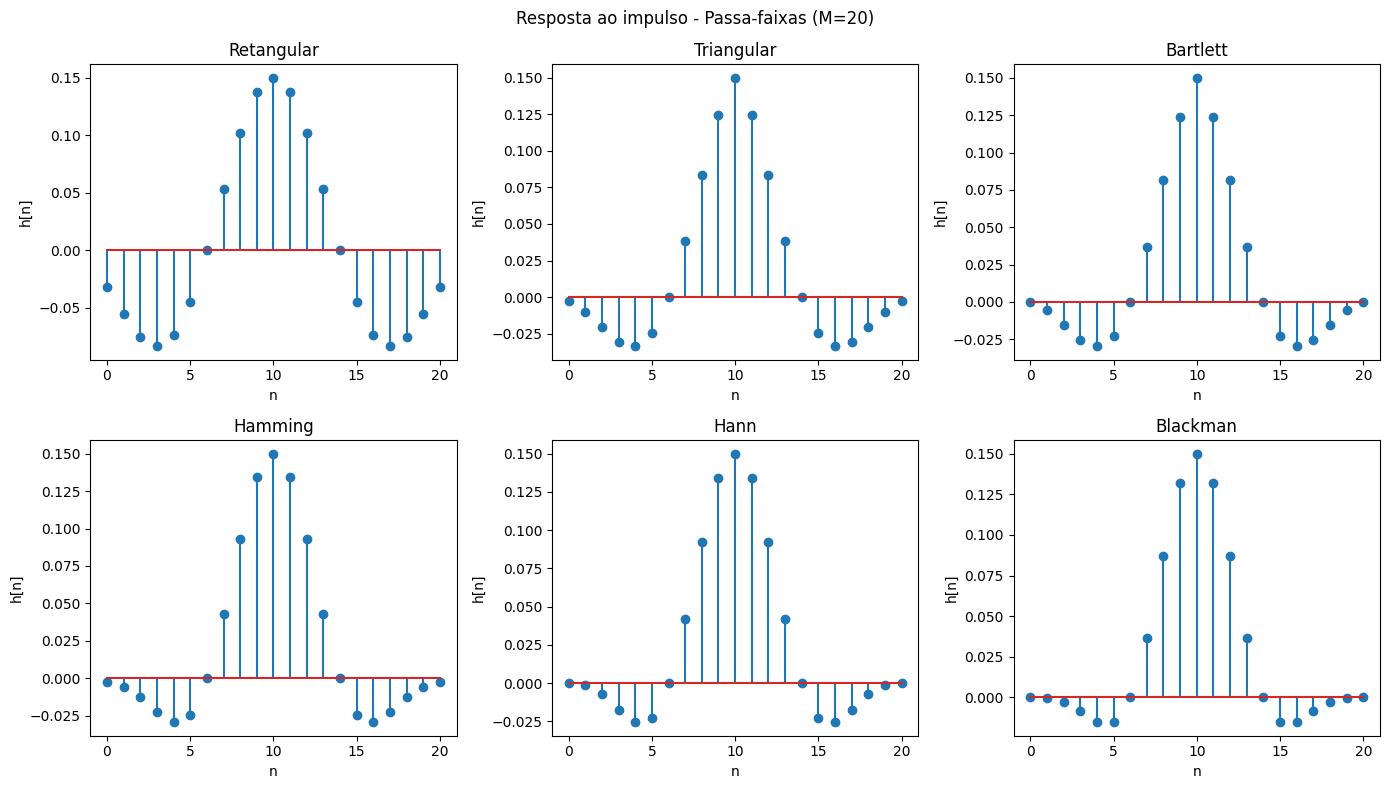

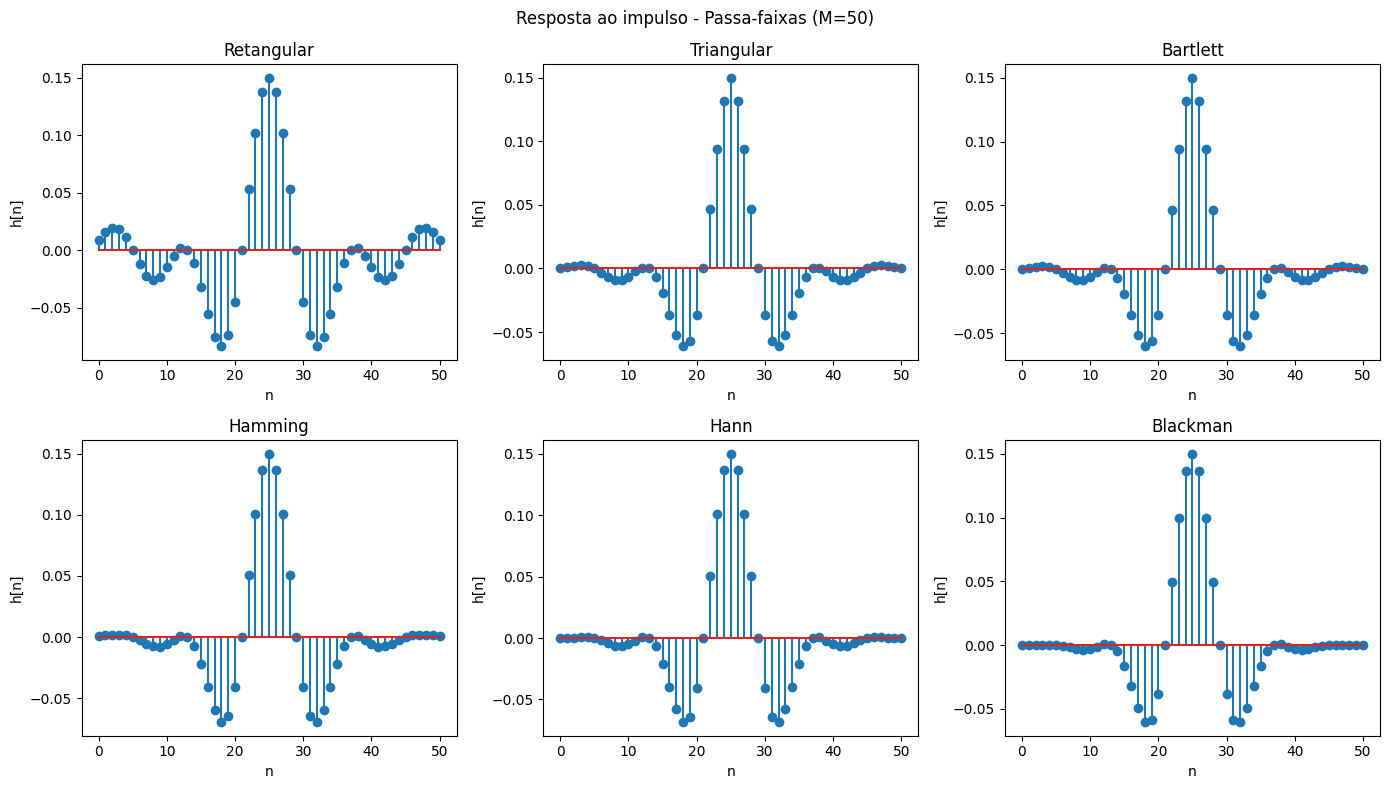

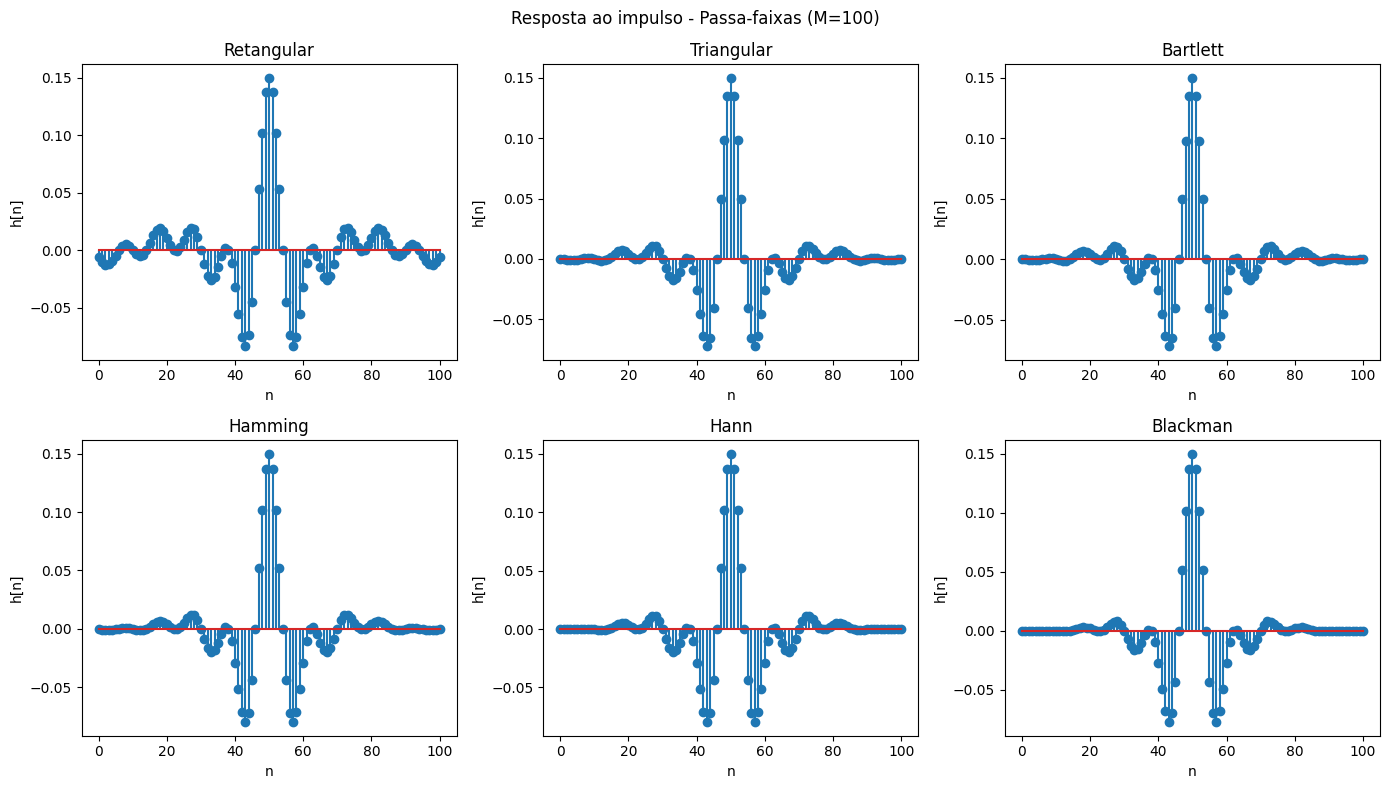

In [17]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        plt.stem(h)

        plt.title(nome)
        plt.xlabel('n')
        plt.ylabel('h[n]')

    plt.suptitle(f'Resposta ao impulso - Passa-faixas (M={M})')

    plt.tight_layout()

    plt.show()

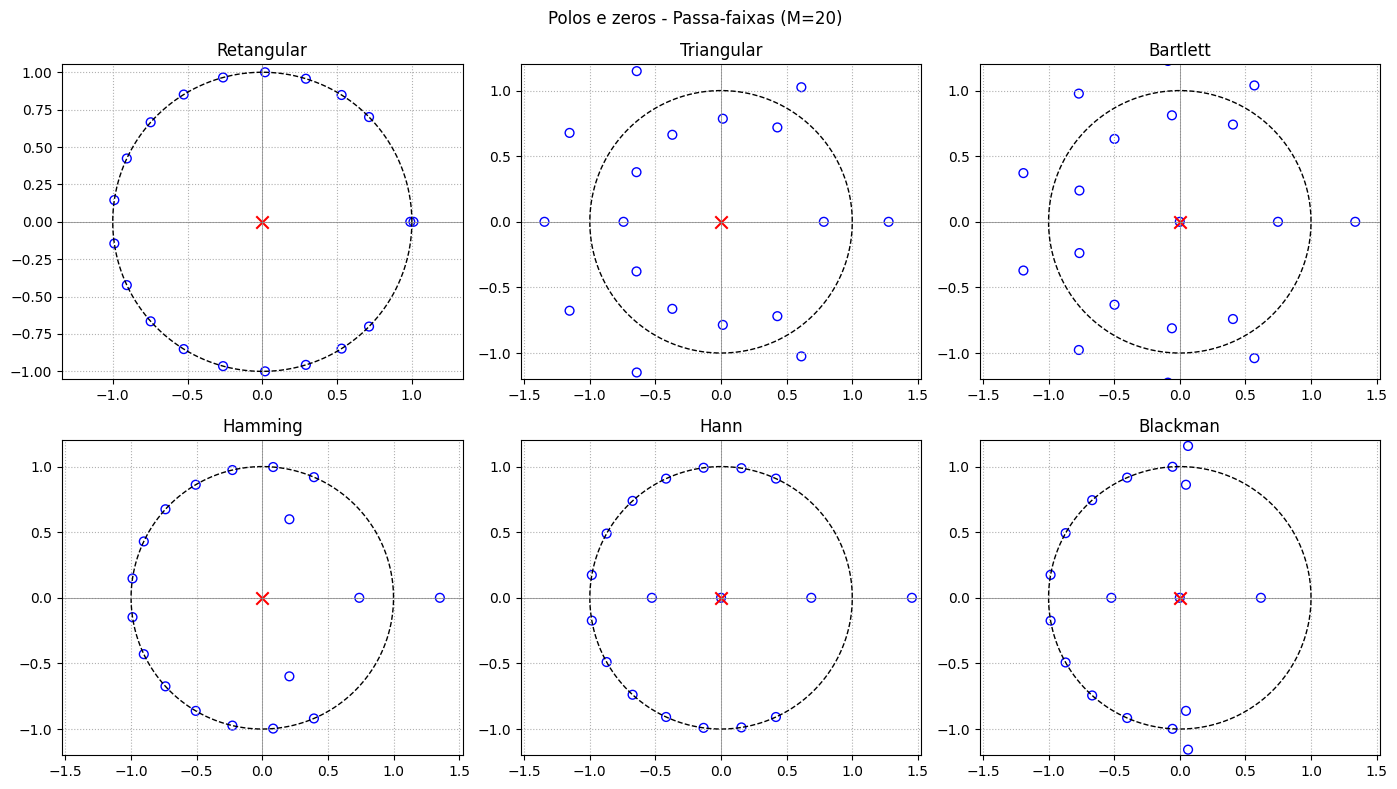

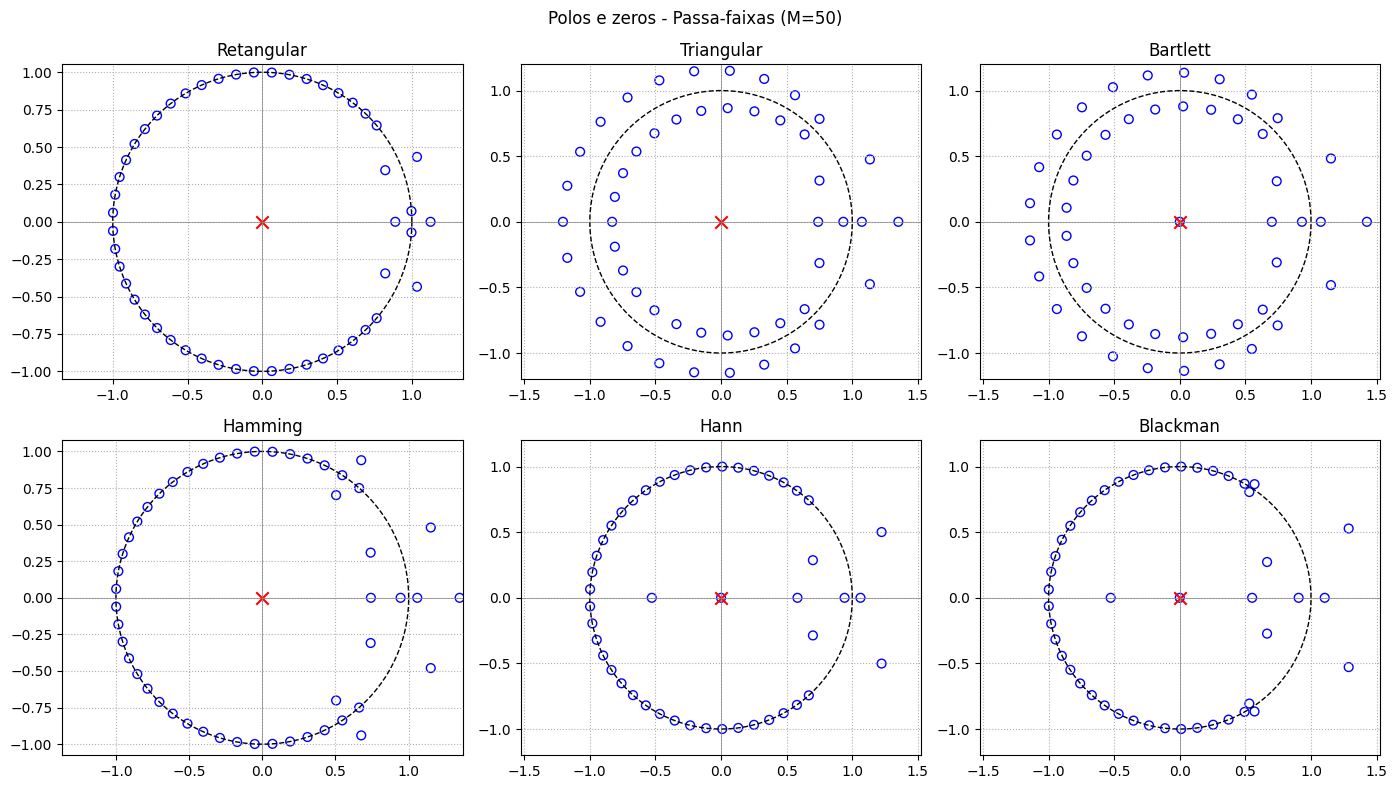

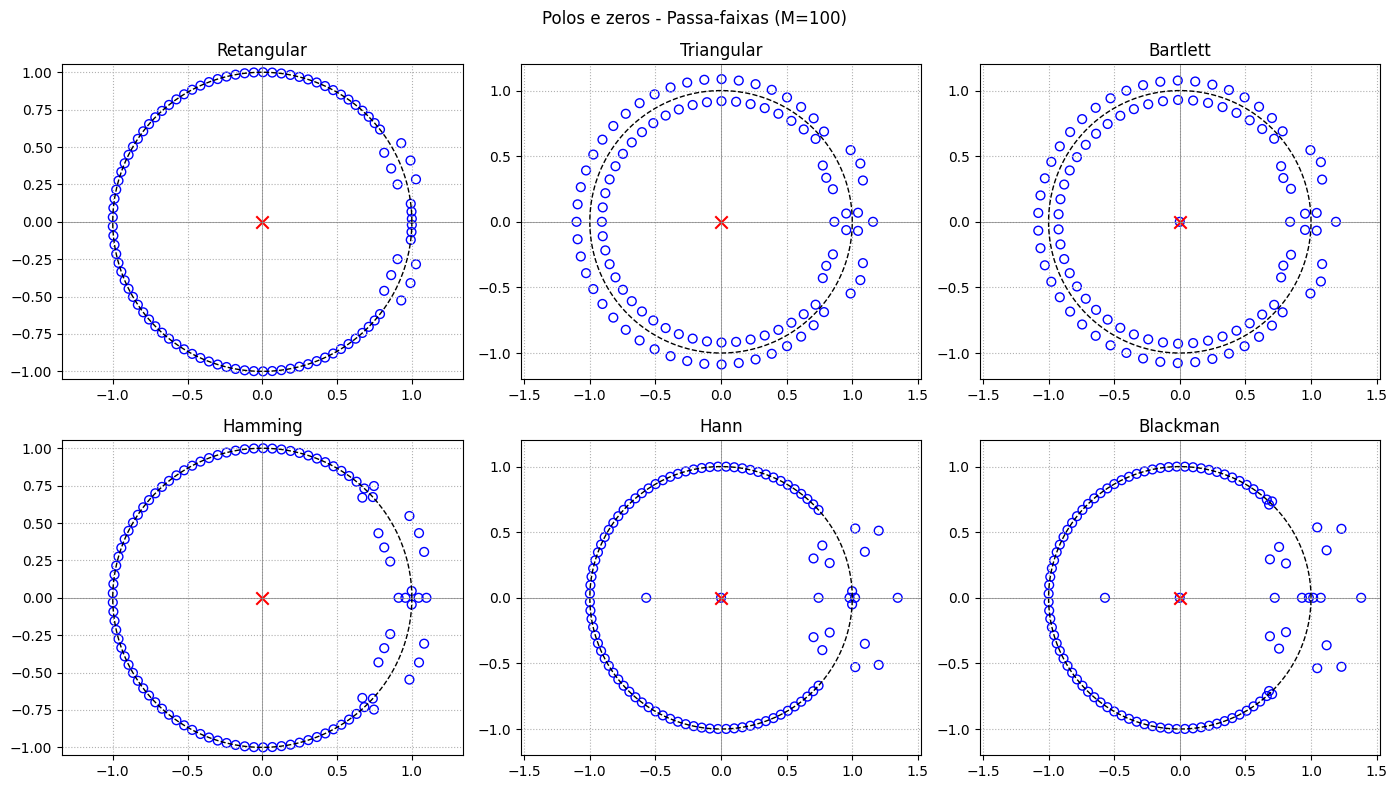

In [18]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        zeros = np.roots(h)

        ang = np.linspace(0, 2*np.pi, 500)

        plt.plot(np.cos(ang),
                 np.sin(ang),
                 'k--',
                 linewidth=1)

        plt.scatter(np.real(zeros),
                    np.imag(zeros),
                    marker='o',
                    facecolors='none',
                    edgecolors='b',
                    s=40)

        plt.scatter(0,
                    0,
                    marker='x',
                    color='r',
                    s=80)

        plt.axhline(0, color='gray', linewidth=0.5)
        plt.axvline(0, color='gray', linewidth=0.5)

        plt.axis('equal')

        plt.xlim(-1.2, 1.2)
        plt.ylim(-1.2, 1.2)

        plt.grid(True, linestyle=':')

        plt.title(nome)

    plt.suptitle(f'Polos e zeros - Passa-faixas (M={M})')

    plt.tight_layout()

    plt.show()

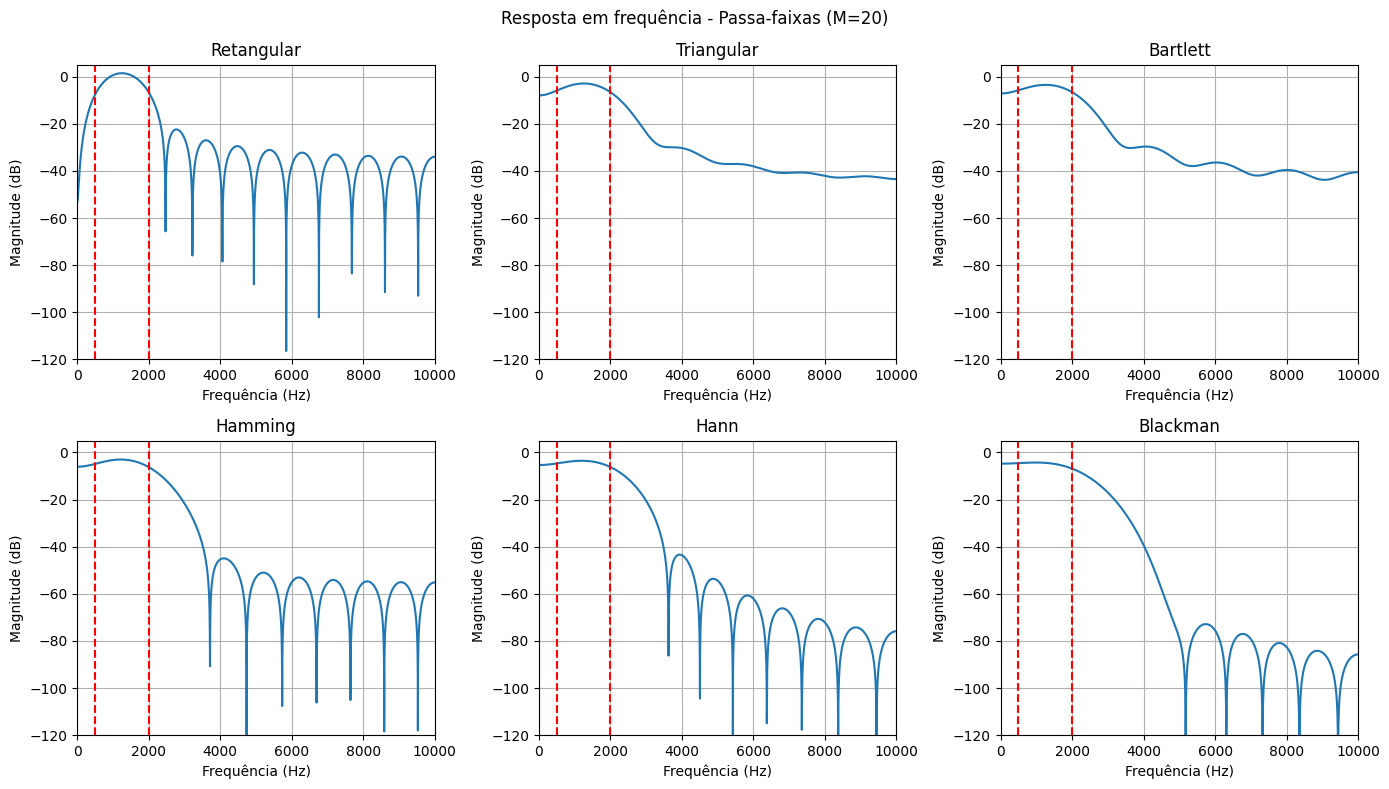

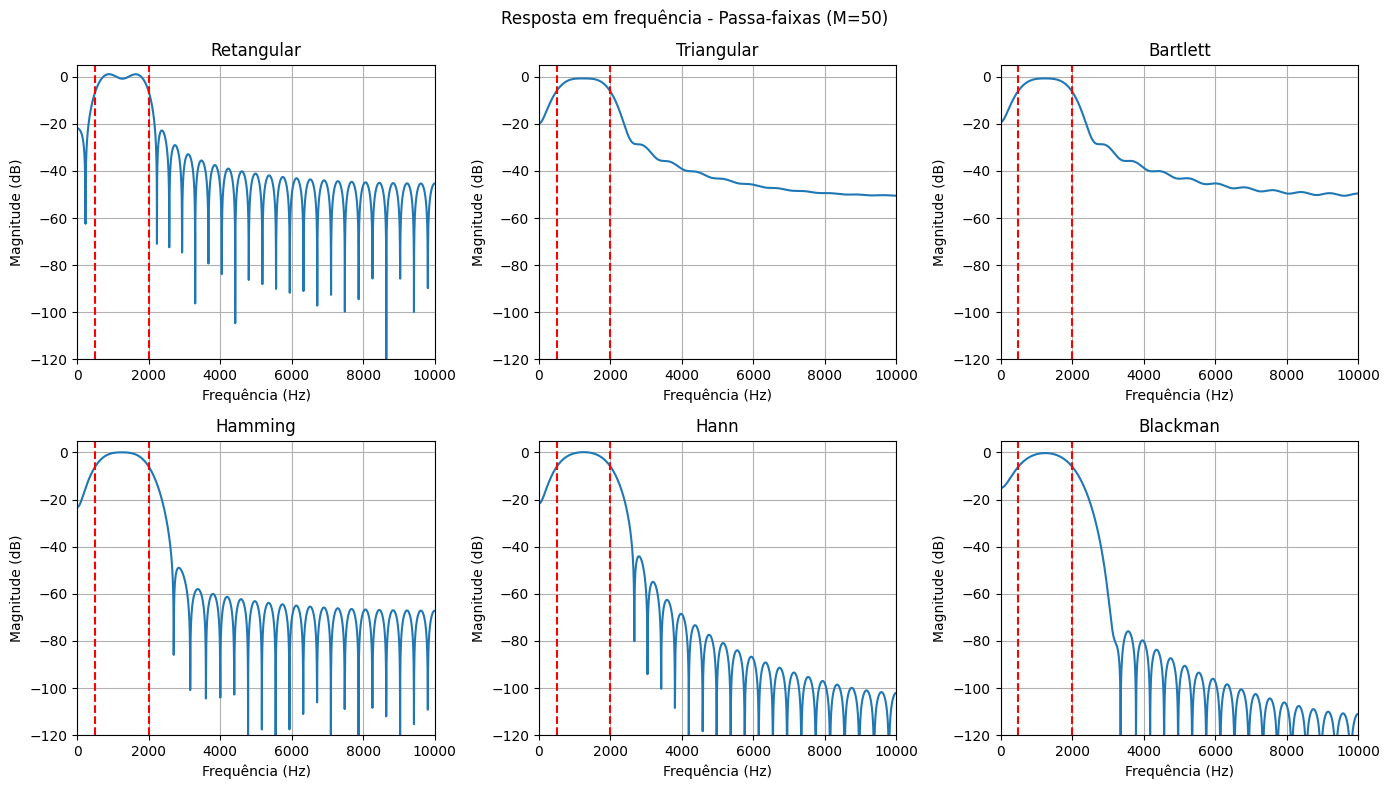

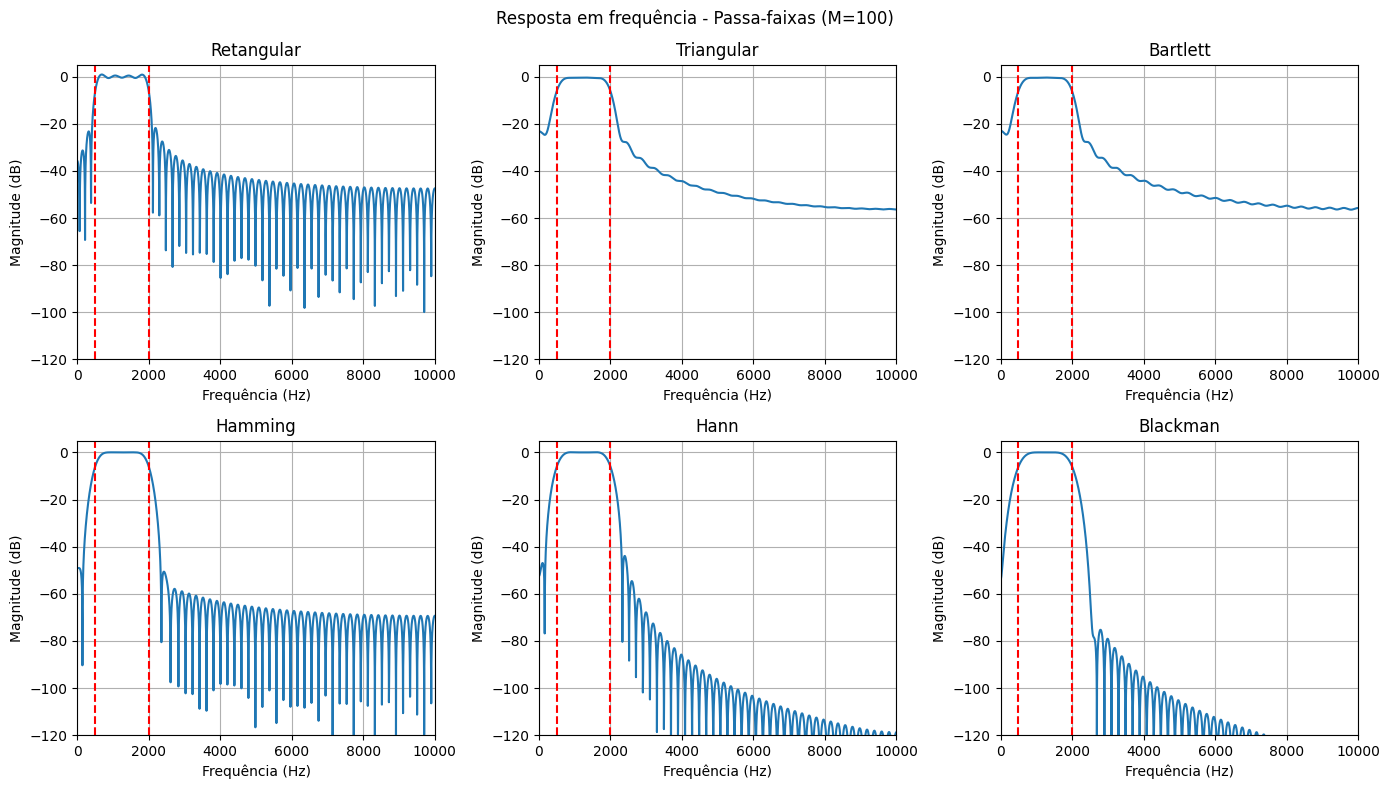

In [19]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        w, H = signal.freqz(h, worN=4096)

        f = w*fs/(2*np.pi)

        plt.plot(f,
                 20*np.log10(np.abs(H)+1e-10))

        plt.axvline(fc1,
                    color='r',
                    linestyle='--')

        plt.axvline(fc2,
                    color='r',
                    linestyle='--')

        plt.xlim(0, fs/2)
        plt.ylim(-120, 5)

        plt.grid()

        plt.title(nome)

        plt.xlabel('Frequência (Hz)')
        plt.ylabel('Magnitude (dB)')

    plt.suptitle(f'Resposta em frequência - Passa-faixas (M={M})')

    plt.tight_layout()

    plt.show()

(d) Rejeita-faixas com fc1 = 1000 Hz e fc2 = 2500 Hz

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

fs = 20000      # Hz

fc1 = 1000      # Hz
fc2 = 2500      # Hz

wc1 = 2*np.pi*fc1/fs
wc2 = 2*np.pi*fc2/fs

ordens = [20, 50, 100]

def ideal_bandstop(M, wc1, wc2):

    n = np.arange(-M//2, M//2 + 1)

    h = np.zeros(len(n))

    for i, ni in enumerate(n):

        if ni == 0:
            h[i] = 1 - (wc2 - wc1)/np.pi
        else:
            h[i] = (np.sin(wc1*ni) - np.sin(wc2*ni)) / (np.pi*ni)

    return h

In [21]:
def triangular_window(M):

    n = np.arange(-M//2, M//2 + 1)

    return -2*np.abs(n)/(M+2) + 1

def bartlett_window(M):

    n = np.arange(-M//2, M//2 + 1)

    return -2*np.abs(n)/M + 1

def get_windows(M):

    return {
        'Retangular': np.ones(M+1),
        'Triangular': triangular_window(M),
        'Bartlett': bartlett_window(M),
        'Hamming': np.hamming(M+1),
        'Hann': np.hanning(M+1),
        'Blackman': np.blackman(M+1)
    }

In [22]:
filtros = {}

for M in ordens:

    h_ideal = ideal_bandstop(M, wc1, wc2)

    filtros[M] = {}

    for nome, janela in get_windows(M).items():

        h = h_ideal * janela

        filtros[M][nome] = h

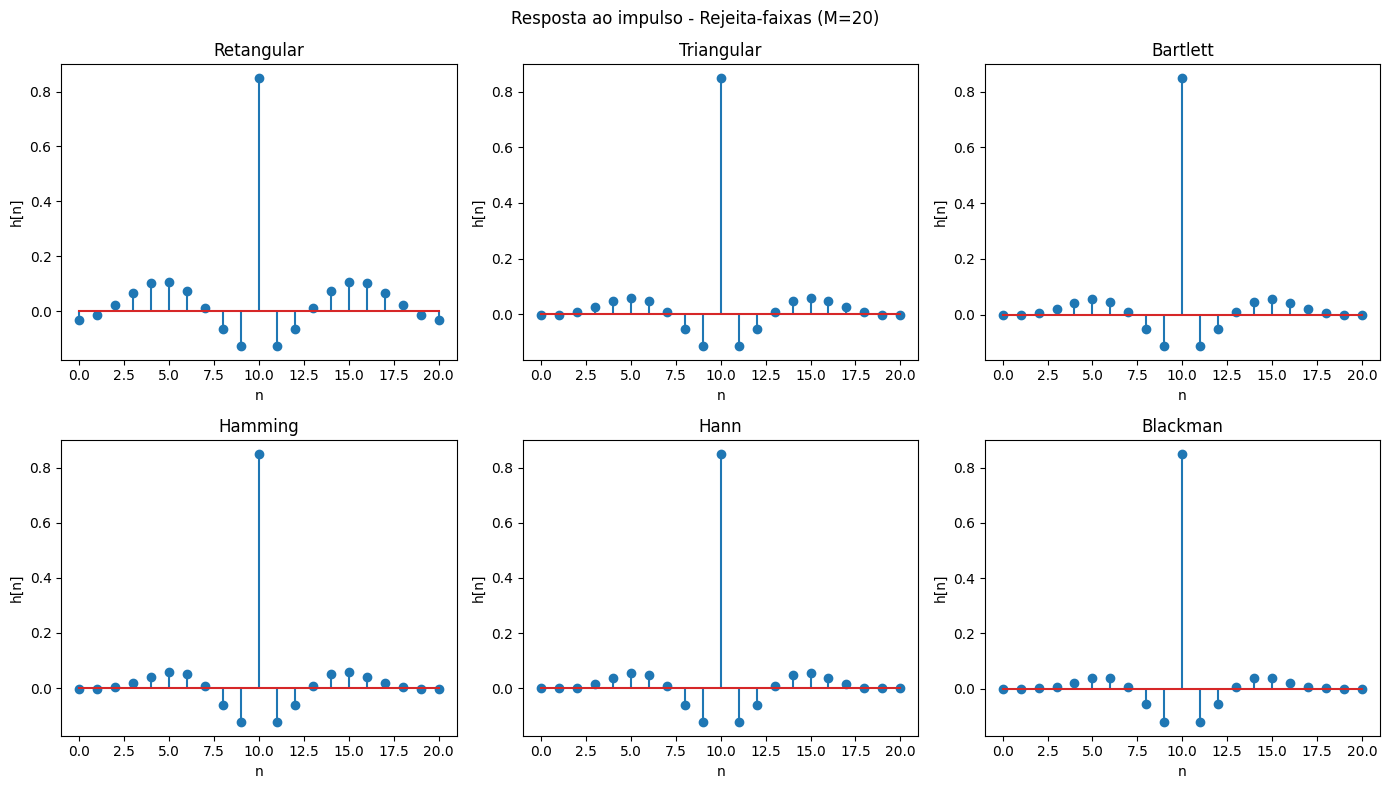

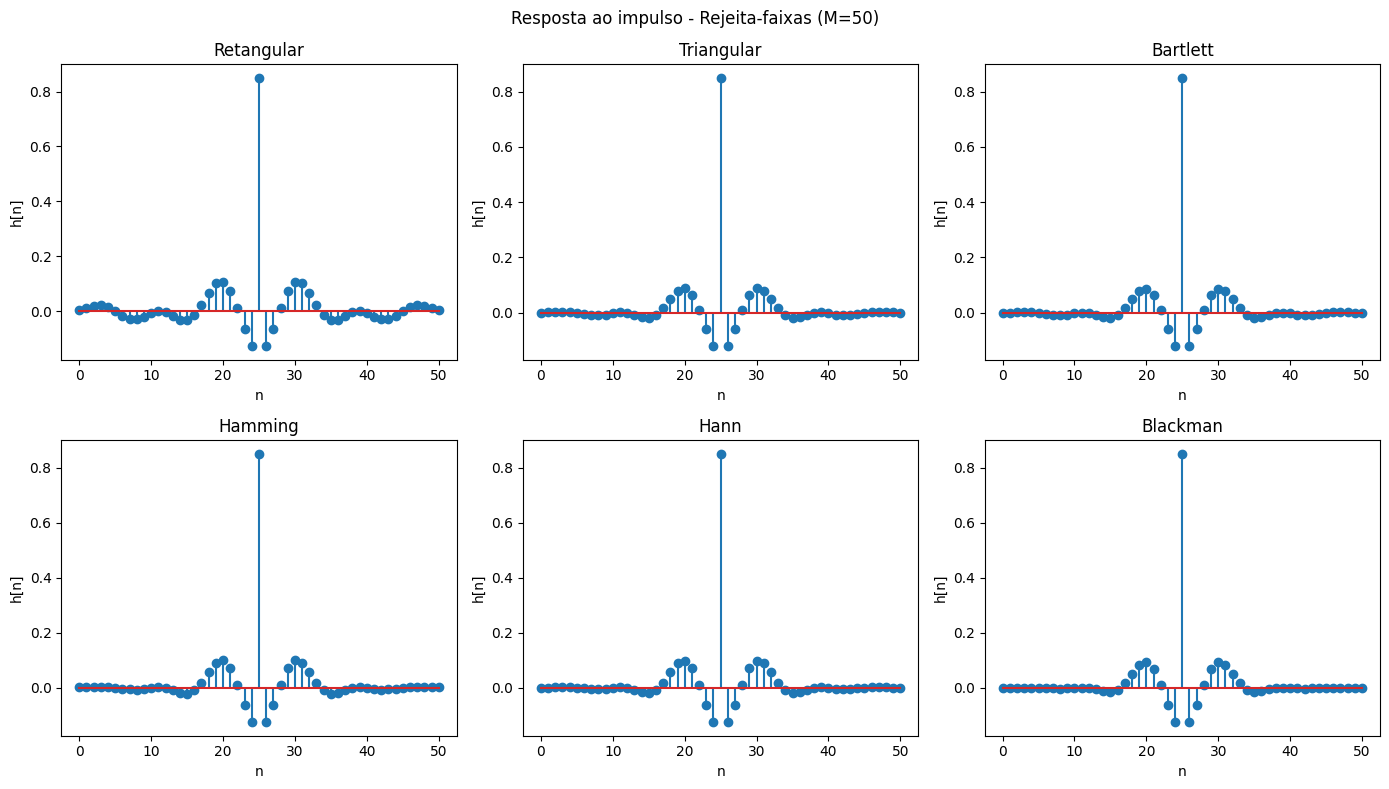

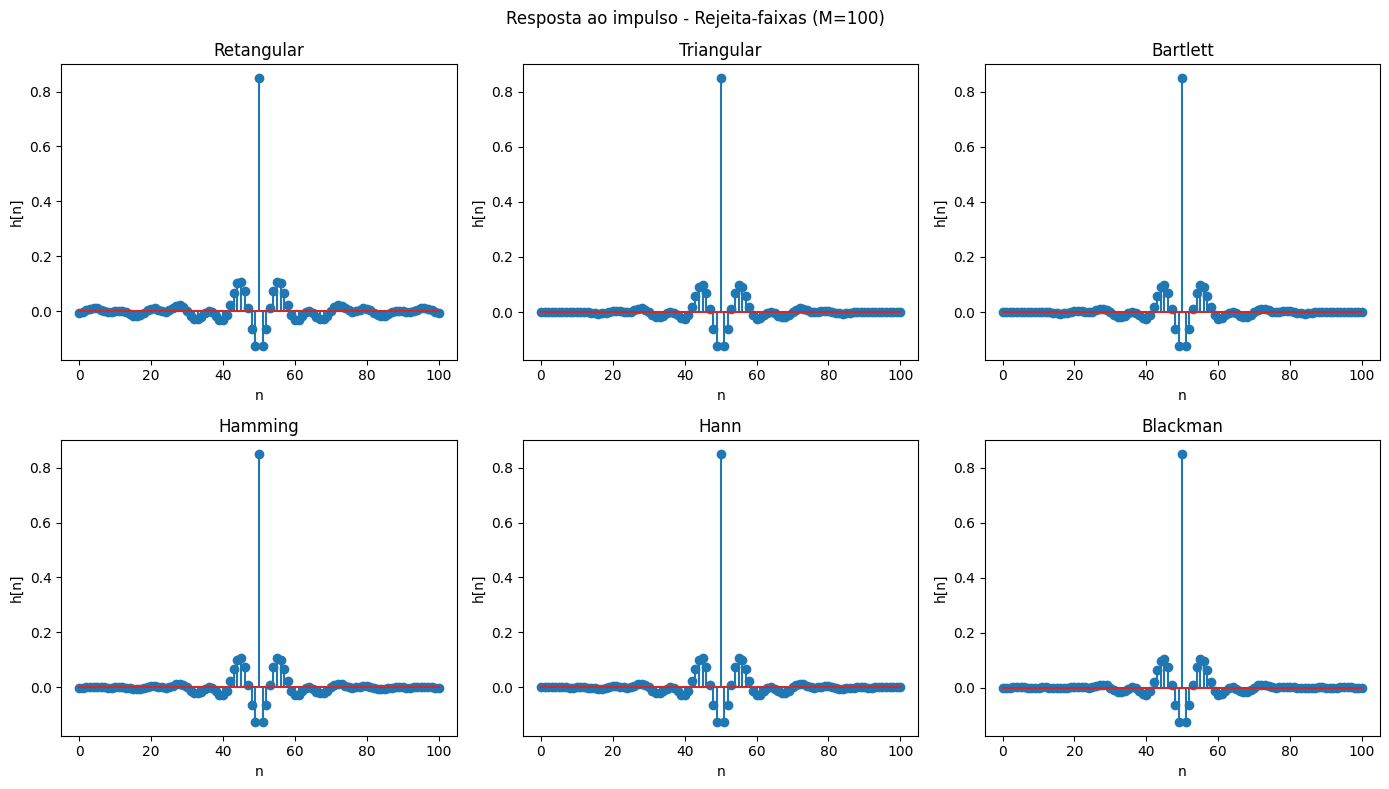

In [23]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        plt.stem(h)

        plt.title(nome)
        plt.xlabel('n')
        plt.ylabel('h[n]')

    plt.suptitle(f'Resposta ao impulso - Rejeita-faixas (M={M})')

    plt.tight_layout()

    plt.show()

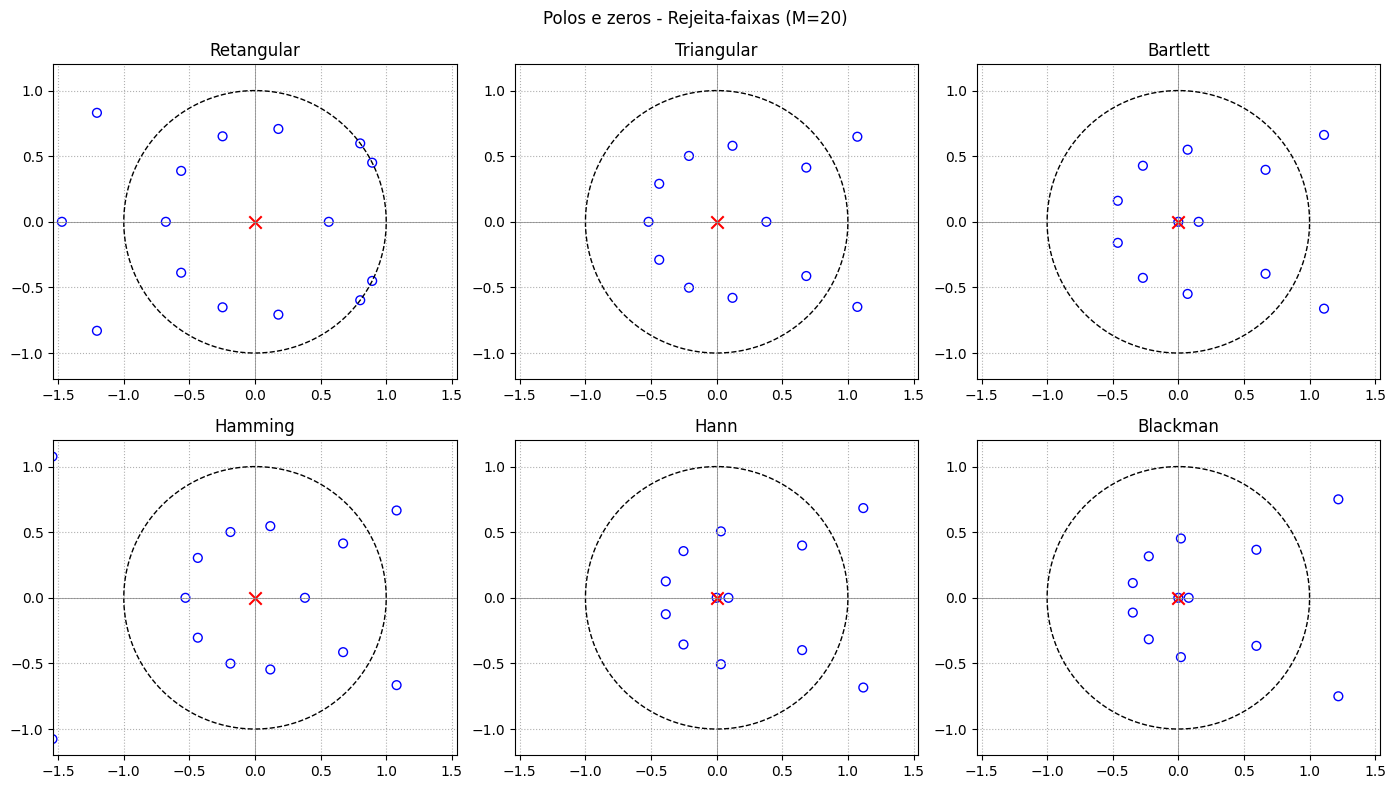

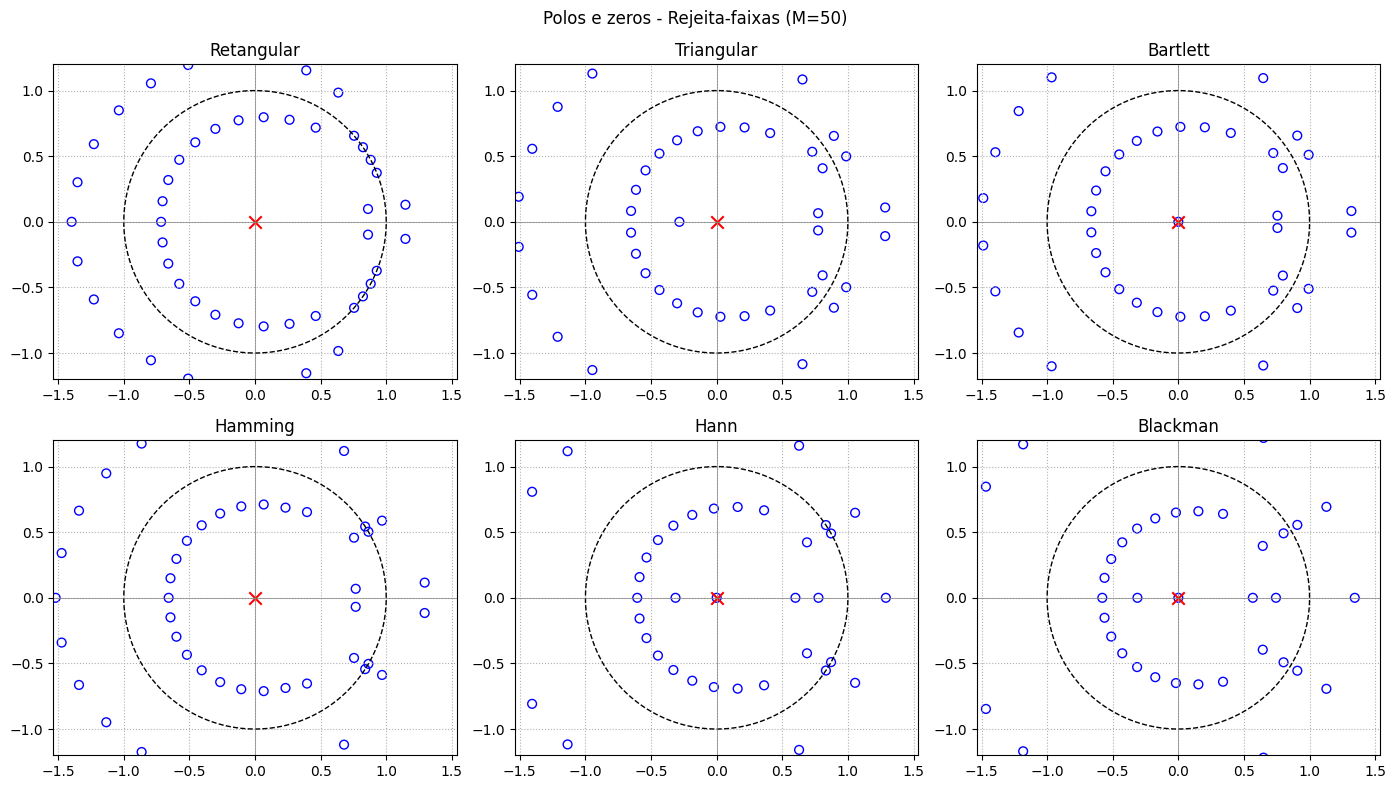

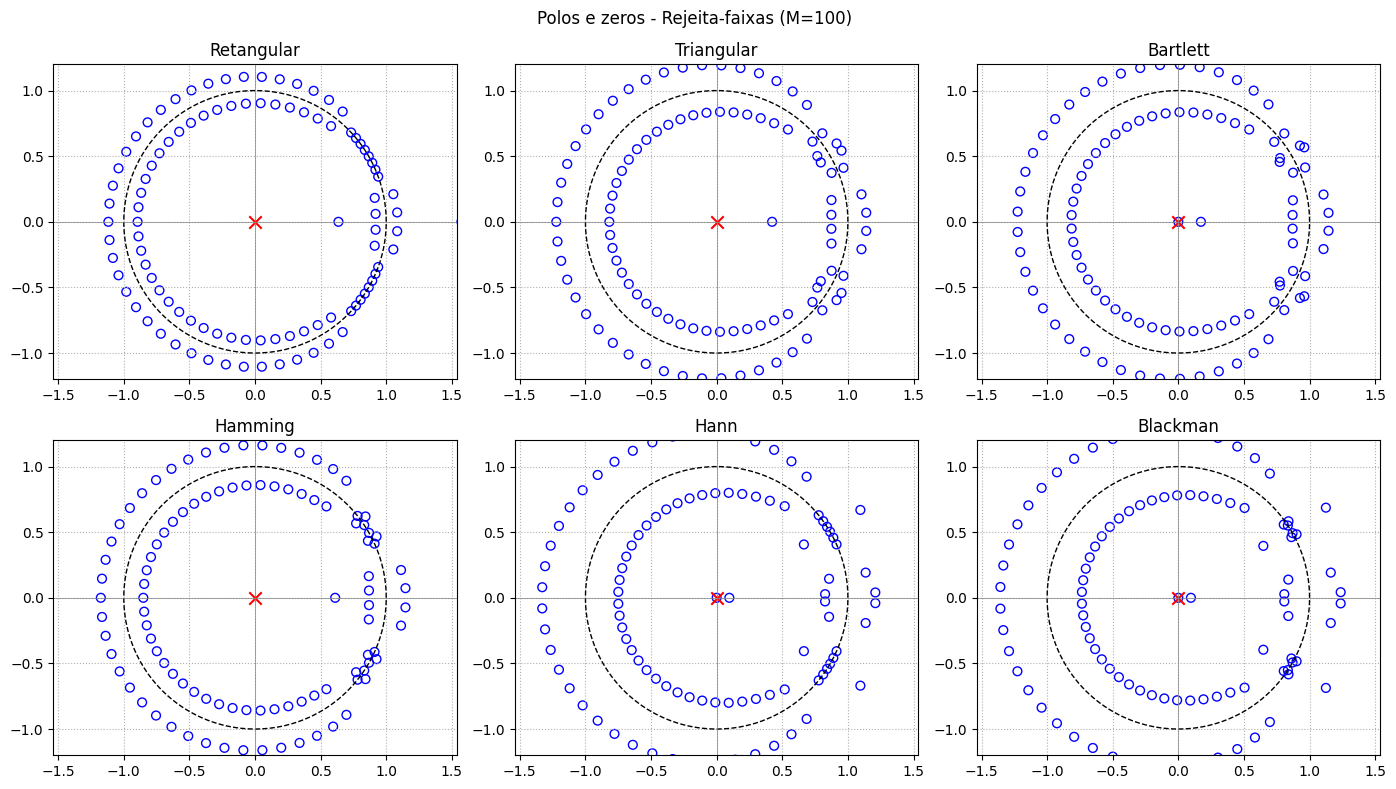

In [24]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        zeros = np.roots(h)

        ang = np.linspace(0, 2*np.pi, 500)

        plt.plot(np.cos(ang),
                 np.sin(ang),
                 'k--',
                 linewidth=1)

        plt.scatter(np.real(zeros),
                    np.imag(zeros),
                    marker='o',
                    facecolors='none',
                    edgecolors='b',
                    s=40)

        plt.scatter(0,
                    0,
                    marker='x',
                    color='r',
                    s=80)

        plt.axhline(0, color='gray', linewidth=0.5)
        plt.axvline(0, color='gray', linewidth=0.5)

        plt.axis('equal')

        plt.xlim(-1.2, 1.2)
        plt.ylim(-1.2, 1.2)

        plt.grid(True, linestyle=':')

        plt.title(nome)

    plt.suptitle(f'Polos e zeros - Rejeita-faixas (M={M})')

    plt.tight_layout()

    plt.show()

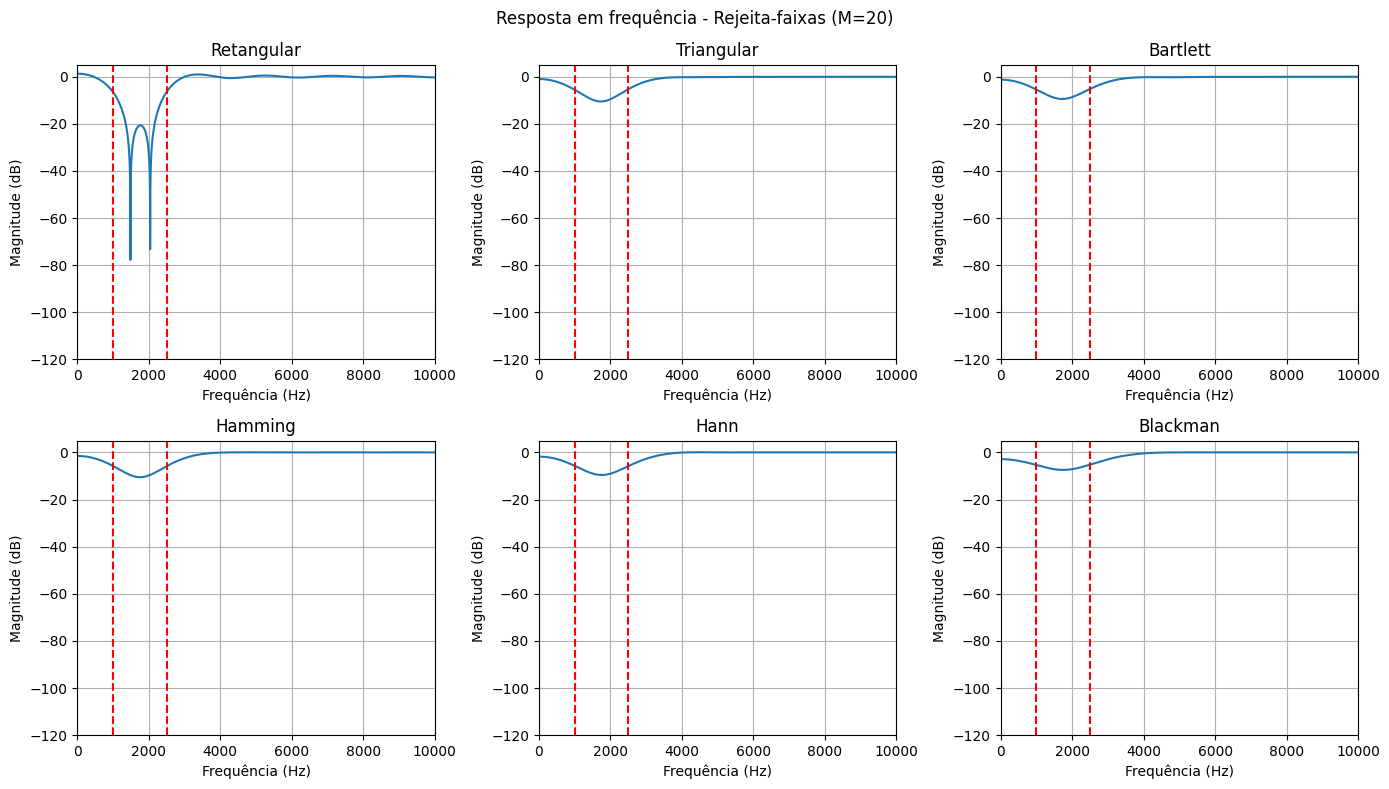

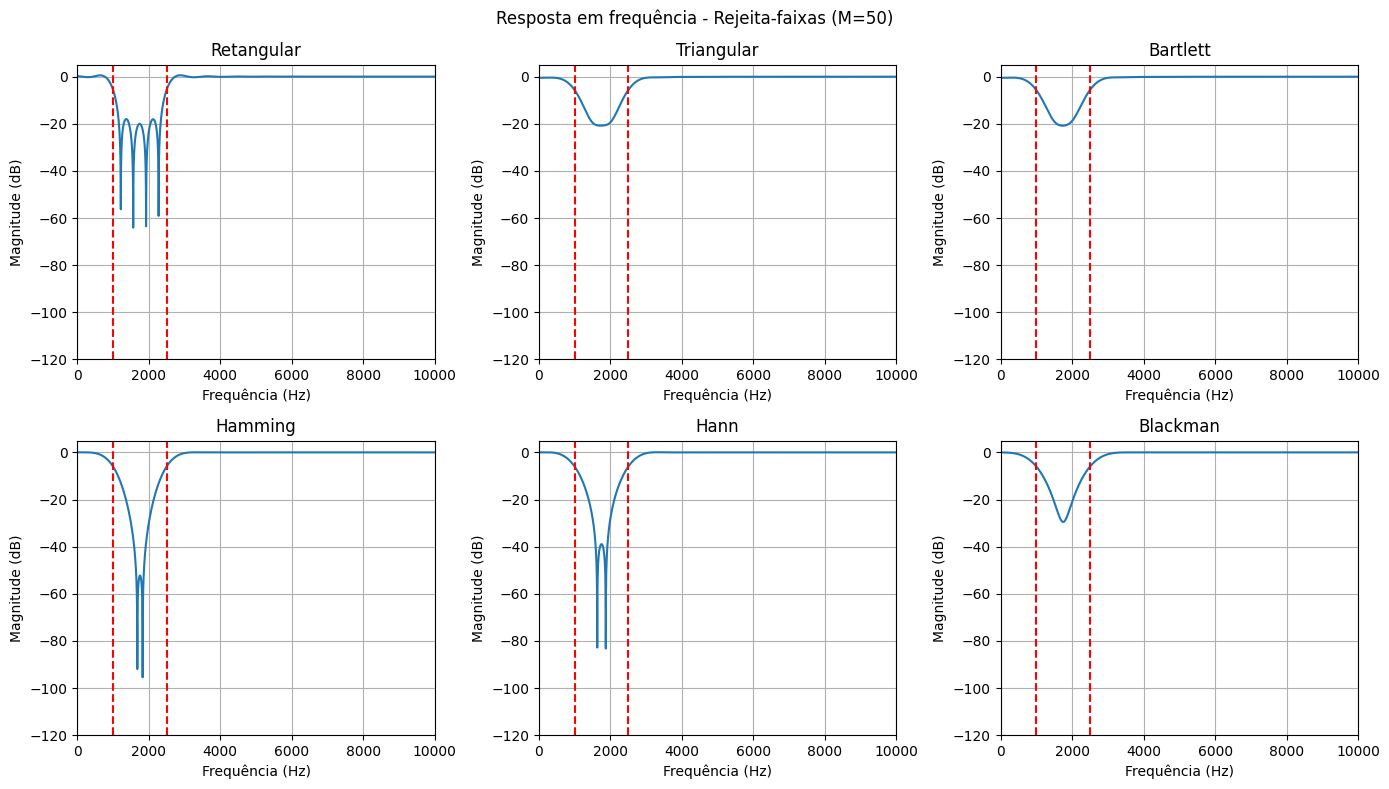

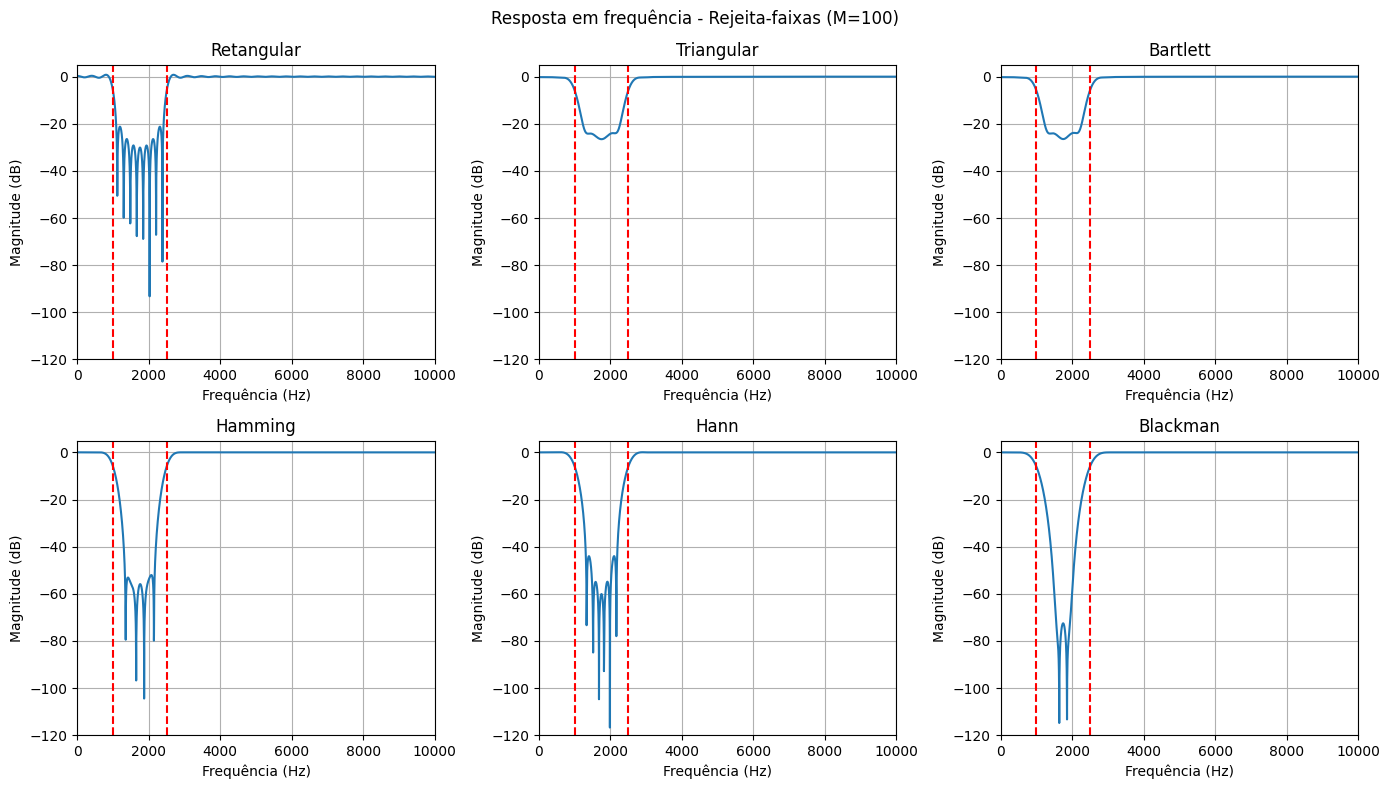

In [25]:
for M in ordens:

    plt.figure(figsize=(14,8))

    for i, (nome, h) in enumerate(filtros[M].items(), 1):

        plt.subplot(2,3,i)

        w, H = signal.freqz(h, worN=4096)

        f = w * fs / (2*np.pi)

        plt.plot(f,
                 20*np.log10(np.abs(H) + 1e-10))

        plt.axvline(fc1,
                    color='r',
                    linestyle='--')

        plt.axvline(fc2,
                    color='r',
                    linestyle='--')

        plt.xlim(0, fs/2)
        plt.ylim(-120, 5)

        plt.grid()

        plt.title(nome)

        plt.xlabel('Frequência (Hz)')
        plt.ylabel('Magnitude (dB)')

    plt.suptitle(f'Resposta em frequência - Rejeita-faixas (M={M})')

    plt.tight_layout()

    plt.show()

2. Para as respostas de módulo mostrada na figura abaixo, derive a resposta ao impulso do filtro ideal. Em seguida, projete um filtro FIR de ordem M ∈ {50, 100} utilizando as janelas retangular, triangular, Hamming, Hann e Blackman. Apresente a resposta ao impulso, o diagrama de polos e zeros e a resposta em frequência dos filtros projetados. Comente os resultados obtidos.

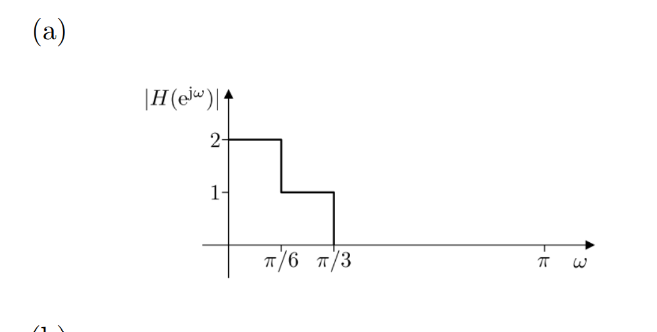

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def projetar_filtro_item2(M, f1, f2, fs, tipo_janela):
    n = np.arange(M + 1)
    n_c = n - M/2

    # Frequências angulares normalizadas
    w1 = 2 * np.pi * f1 / fs
    w2 = 2 * np.pi * f2 / fs

    # Evitar divisão por zero no ponto central (n = M/2)
    n_c_safe = n_c.copy()
    n_c_safe[n_c == 0] = 1e-10

    # Resposta ao impulso ideal (h_d)
    h_d = (np.sin(w2 * n_c_safe) / (np.pi * n_c_safe)) - \
          (np.sin(w1 * n_c_safe) / (np.pi * n_c_safe))

    # Correção no ponto central (aplicação de L'Hôpital)
    h_d[n == M/2] = (w2 - w1) / np.pi

    # Aplicar a janela
    w = obter_janela(M, tipo_janela) # Função implementada anteriormente
    return h_d * w

# Exemplo: M=100, f1=1000, f2=4000
h = projetar_filtro_item2(100, 1000, 4000, 20000, 'hann')

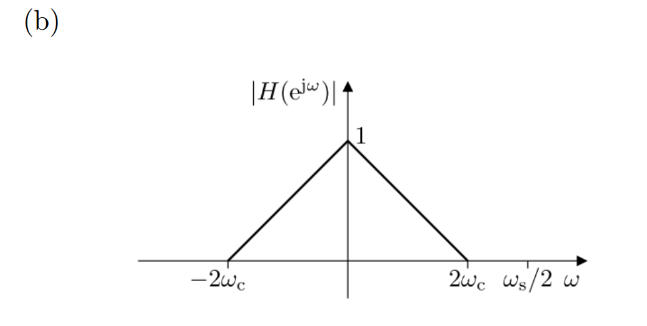

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def projetar_filtro_item2b(M, fc, fs, tipo_janela):
    n = np.arange(M + 1)
    n_c = n - M/2
    wc = 2 * np.pi * fc / fs

    # 1. Resposta ideal (Impulso - Passa-Baixas)
    n_c_safe = n_c.copy()
    n_c_safe[n_c == 0] = 1e-10

    h_pb = np.sin(wc * n_c_safe) / (np.pi * n_c_safe)
    h_pb[n == M/2] = wc / np.pi

    h_d = -h_pb
    h_d[n == M/2] += 1

    # 2. Aplicar a janela
    w = obter_janela(M, tipo_janela) # Mesma função definida nos passos anteriores
    return h_d * w

# Exemplo: M=100, fc=3000, fs=20000
h = projetar_filtro_item2b(100, 3000, 20000, 'blackman')

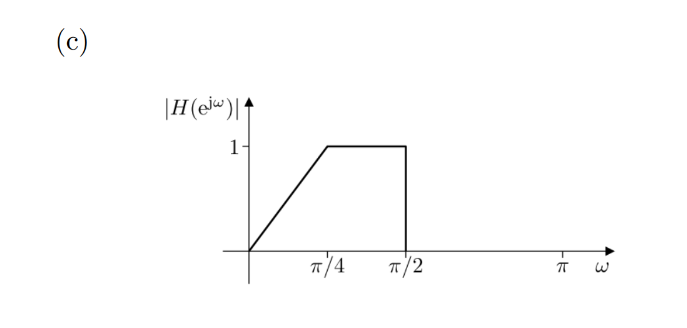

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def projetar_rejeita_faixas_item2c(M, f1, f2, fs, tipo_janela):
    n = np.arange(M + 1)
    n_c = n - M/2
    w1 = 2 * np.pi * f1 / fs
    w2 = 2 * np.pi * f2 / fs

    # 1. Filtro Passa-Faixa ideal (base)
    n_c_safe = n_c.copy()
    n_c_safe[n_c == 0] = 1e-10
    h_pf = (np.sin(w2 * n_c_safe) - np.sin(w1 * n_c_safe)) / (np.pi * n_c_safe)
    h_pf[n == M/2] = (w2 - w1) / np.pi

    # 2. Inversão (Delta - Passa-Faixa)
    h_d = -h_pf
    h_d[n == M/2] += 1

    # 3. Janelamento
    w = obter_janela(M, tipo_janela)
    return h_d * w

3. Deseja-se aplicar técnicas de processamento digital
de sinais para análise, modelagem e remoção de interferências em um sinal de áudio corrompido utilizando
filtros FIR.

 Considere o arquivo de áudio handel.wav. Seja x(t) o
sinal de áudio original e construa um sinal contaminado
dado por

y(t) = x(t) + 0.05 cos(200πt) + 0.075 sin(4000πt) + n(t),

onde x(t) é o sinal de áudio proveniente do arquivo
handel.wav, o termo 0.05 cos(200πt) representa uma
interferência senoidal de baixa frequência, o termo
0.075 sin(4000πt) representa uma interferência tonal de
alta frequência e e n(t) é um sinal de ruído branco com
variância σ
2 ∈ {10^(−2), 10^(−1), 1}.

Faça os itens a seguir.

(a) Projete um sistema de filtragem utilizando filtros
FIR para recuperar o sinal original. Para cada filtro projetado, apresente o diagrama de polos e zeros, sua resposta em frequência. Compare com os filtros projetados
na Aula Prática 6.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal

def filtrar_sinal(sinal_contaminado, coeficientes_h):
    # A convolução aplica o filtro ao sinal (y[n] = x[n] * h[n])
    # mode='same' mantém o tamanho do sinal original
    sinal_filtrado = np.convolve(sinal_contaminado, coeficientes_h, mode='same')
    return sinal_filtrado

# --- Código para criar o sinal 'y' ---

# 1. Carregar o sinal de áudio original x(t)
# Certifique-se de que o arquivo 'handel.wav' está no seu Google Drive ou no ambiente Colab
# Exemplo: '/content/drive/MyDrive/handel.wav'
# Você pode precisar ajustar o caminho do arquivo.

# Define o caminho para o arquivo handel.wav
# Se o arquivo não estiver aqui, faça o upload para o diretório raiz do seu Google Drive
# ou ajuste o caminho para onde você o salvou.
file_path = '/content/drive/MyDrive/handel.wav'

# Lê o arquivo .wav
fs_audio, x_raw = wavfile.read(file_path)

# Converte o sinal para float para cálculos (normaliza para -1 a 1 se for int)
if x_raw.dtype == 'int16':
    x_raw = x_raw.astype(float) / (2**15)
elif x_raw.dtype == 'int32':
    x_raw = x_raw.astype(float) / (2**31)

# Define a taxa de amostragem desejada para o projeto (20000 Hz)
fs_projeto = 20000

# Se a taxa de amostragem do áudio for diferente, resample
if fs_audio != fs_projeto:
    num_samples_resampled = int(len(x_raw) * (fs_projeto / fs_audio))
    x = signal.resample(x_raw, num_samples_resampled)
    fs = fs_projeto
else:
    x = x_raw
    fs = fs_audio

# Garante que x seja um array 1D se for estéreo
if x.ndim > 1:
    x = x[:, 0] # Pega apenas um canal

N = len(x) # Número de amostras do sinal
t = np.arange(N) / fs # Vetor de tempo

# 2. Gerar as interferências senoidais
interferencia_baixa_frequencia = 0.05 * np.cos(200 * np.pi * t)
interferencia_alta_frequencia = 0.075 * np.sin(4000 * np.pi * t)

# 3. Gerar o ruído branco (exemplo com variância 0.01)
# Conforme a descrição, a variância (sigma^2) pode ser 0.01, 0.1 ou 1
variance_noise = 0.01 # Exemplo: 10^(-2)
sigma_noise = np.sqrt(variance_noise)
n_t = np.random.normal(0, sigma_noise, N)

# 4. Criar o sinal contaminado y(t)
y = x + interferencia_baixa_frequencia + interferencia_alta_frequencia + n_t

# Visualização do sinal contaminado (opcional)
# plt.figure(figsize=(12, 4))
# plt.plot(t, y)
# plt.title('Sinal Contaminado y(t)')
# plt.xlabel('Tempo (s)')
# plt.ylabel('Amplitude')
# plt.grid(True)
# plt.show()

# Exemplo de uso do filtro (certifique-se de que 'h' está definido de um dos exercícios anteriores)
# A variável 'h' já está no kernel do estado fornecido, então será usada aqui.
sinal_recuperado = filtrar_sinal(y, h)

# Você pode adicionar código aqui para plotar o sinal recuperado
# plt.figure(figsize=(12, 4))
# plt.plot(t, sinal_recuperado)
# plt.title('Sinal Recuperado')
# plt.xlabel('Tempo (s)')
# plt.ylabel('Amplitude')
# plt.grid(True)
# plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/handel.wav'

(b) Filtre o sinal contaminado utilizando o sistema projetado e compare o sinal original x(t), o sinal contaminado y(t) e o sinal recuperado ^x(t). Apresente
comparações no domínio do tempo e no domínio da
frequência. Compare com os resultados obtidos na Aula
Prática 6.

(c) Avalie quantitativamente o desempenho do sistema
de filtragem utilizando métricas como relação sinal-ruído
(SNR), erro quadrático médio (MSE) e potência do ruído
residual. Compare os resultados obtidos para os diferentes valores de variância do ruído branco. Compare
com os resultados obtidos na Aula Prática 6.


(d) Realize uma avaliação subjetiva do áudio recuperado, discutindo inteligibilidade, presença de distorções,
atenuaçaão das interferências e impacto perceptual do
ruído residual. Compare com os resultados obtidos na
Aula Prática 6.

(e) Quantize os coeficientes dos filtros projetados utilizando b ∈ {2, 4, 8, 16} bits. Compare os filtros originais
e quantizados em termos de resposta em frequência,
posição dos polos e zeros, estabilidade e qualidade do
áudio recuperado. Comente os resultados obtidos e compare com os resultados da Aula Prática 6.e